<a href="https://colab.research.google.com/github/kyd4947/UnivStudent/blob/BigData_Project/%EA%B9%80%EC%9C%A0%EB%8F%99_%ED%99%98%EC%9C%A8_%EC%98%88%EC%B8%A1_%EB%B6%84%EC%84%9D(KRW_Currency_Exchange_Rate).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2024년 - 1학기 빅데이터 분석 프로젝트


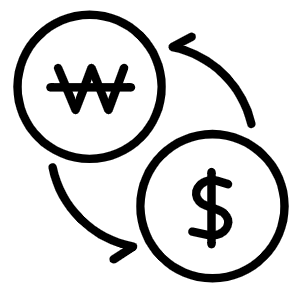

주제 : 원화 - 기축통화(준기축통화 포함 / 금,은 제외) 환율 추이 => 21세기 (2001~2024)

프로젝트의 최종 목표 : 기축 통화 및 무역통화(금, 은 제외)의 환율을 분석하고, 어느 시기에 큰 변화가 있었는지 확인할 수 있도록 하는 것이 목표

##데이터 전처리

###필요한 라이브러리 임포트

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose   #시계열 분해

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###데이터 로드 및 데이터 프레임 확인

In [ ]:
rates = pd.read_csv('/content/drive/MyDrive/KRW_KeyCur_ExRa.csv')
rates.head()

,Date,Dollar,Yuan,Yen,Euro,Pound_Sterling,Swiss_Franc
0,2001-01-02,1259.7,152.19,1099.07,1185.38,1885.02,782.18
1,2001-01-03,1267.8,153.15,1108.07,1205.49,1903.35,792.33
2,2001-01-04,1285.4,155.29,1128.53,1193.24,1914.15,788.35
3,2001-01-05,1249.3,150.92,1078.01,1190.90,1876.82,778.38
4,2001-01-08,1267.8,153.16,1088.71,1215.06,1906.33,793.37


###각 열의 데이터 타입 확인

In [ ]:
rates.dtypes

Date               object
Dollar            float64
Yuan              float64
Yen               float64
Euro              float64
Pound_Sterling    float64
Swiss_Franc       float64
dtype: object

###Date 열을 datetime format(날짜 시간 형식)으로 전환

In [ ]:
rates['Date'] = pd.to_datetime(rates['Date'])

###Null 값을 확인

In [ ]:
rates.isnull().sum()

Date              0
Dollar            0
Yuan              0
Yen               0
Euro              0
Pound_Sterling    0
Swiss_Franc       0
dtype: int64

###이상치 확인

In [ ]:
currency_columns = rates.columns.drop('Date')     #Date열을 제외한 나머지 열을 통화열로 선택

Q1 = rates[currency_columns].quantile(0.25)       #1사분위 계산 하위 25%
Q3 = rates[currency_columns].quantile(0.75)       #3사분위 계산 상위 25%
IQR = Q3 - Q1                                     #데이터의 중간 50% 범위

((rates[currency_columns] < (Q1 - 1.5 * IQR)) | (rates[currency_columns] > (Q3 + 1.5 * IQR))).sum()   #이상치 탐색

Dollar             99
Yuan                6
Yen               746
Euro              274
Pound_Sterling     13
Swiss_Franc         0
dtype: int64

###이상치 값 다루기

In [ ]:
for column in currency_columns:               #'Date'열을 제외한 각 통화 열에 반복 작업 수행
  median = rates[column].median()             #각 통화 열의 중앙 값을 계산
  Q1 = rates[column].quantile(0.25)           #각 통화열의 1사분위수 계산
  Q3 = rates[column].quantile(0.75)           #각 통화열의 3사분위수 계산
  IQR = Q3 - Q1                               #사분위수 범위 계산
  rates.loc[((rates[column] < (Q1 - 1.5 * IQR)) | (rates[column] > (Q3 + 1.5 * IQR))), column] = np.nan     #IQR 기준으로 이상치를 탐지하고 해당 값들은 NaN(Not a Number)로 대체
  rates.fillna(median, inplace = True)        #Nan으로 대체된 값을 중앙값으로 대체

###환율 테이블 최종 확인

In [ ]:
rates.head()

,Date,Dollar,Yuan,Yen,Euro,Pound_Sterling,Swiss_Franc
0,2001-01-02,1259.7,152.19,1099.07,1185.38,1885.02,782.18
1,2001-01-03,1267.8,153.15,1108.07,1205.49,1903.35,792.33
2,2001-01-04,1285.4,155.29,1128.53,1193.24,1914.15,788.35
3,2001-01-05,1249.3,150.92,1078.01,1190.90,1876.82,778.38
4,2001-01-08,1267.8,153.16,1088.71,1215.06,1906.33,793.37


## 탐색적 데이터 분석(EDA, Exploratory Data Analysis)

###환율 테이블의 요약된 정보 확인

In [ ]:
rates.describe()

,Date,Dollar,Yuan,Yen,Euro,Pound_Sterling,Swiss_Franc
count,5811,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000
mean,2012-09-13 10:24:57.986577152,1142.786921,163.557802,1013.396773,1350.773743,1741.524538,1092.397548
min,2001-01-02 00:00:00,902.200000,116.210000,746.150000,1083.590000,1336.390000,712.050000
25%,2006-11-09 12:00:00,1082.750000,148.630000,962.440000,1266.620000,1591.740000,899.240000
50%,2012-08-31 00:00:00,1143.500000,169.260000,1024.810000,1346.980000,1752.750000,1149.550000
75%,2018-07-21 12:00:00,1199.150000,178.620000,1059.925000,1426.550000,1861.870000,1218.505000
max,2024-06-07 00:00:00,1386.300000,223.570000,1327.740000,1714.280000,2255.200000,1554.030000
std,NaN,104.952760,21.499170,106.433081,115.790477,184.260289,206.052564


###기축통화 및 무역통화(금, 은 제외)의 원화 가격을 시각화(Plot 사용)

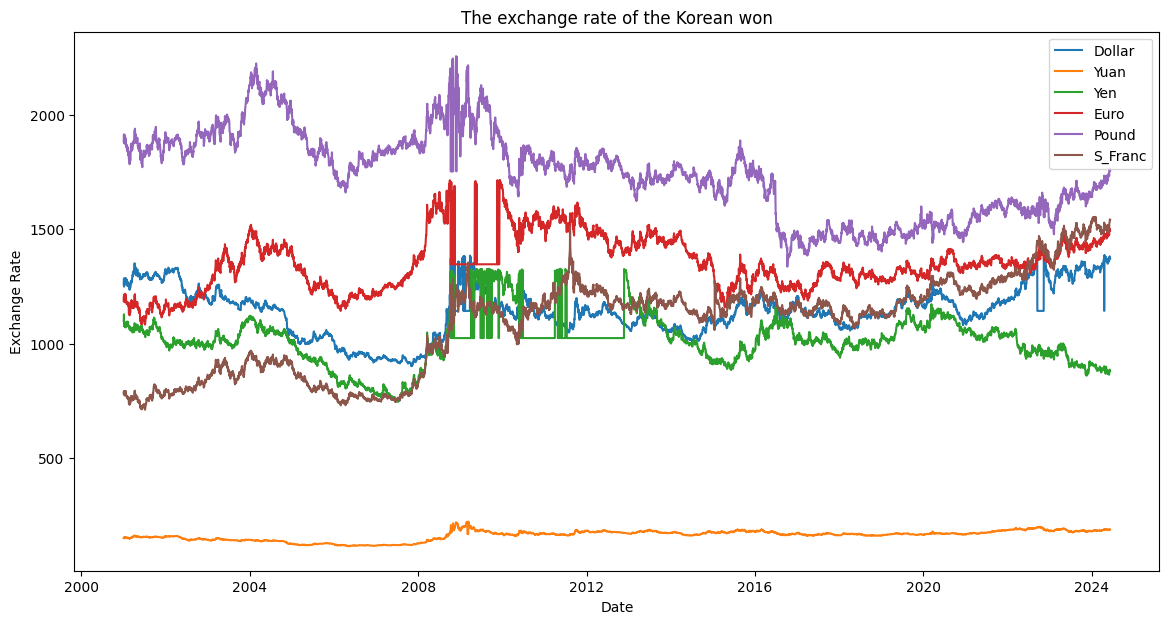

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(rates['Date'], rates['Dollar'], label='Dollar')
plt.plot(rates['Date'], rates['Yuan'], label='Yuan')
plt.plot(rates['Date'], rates['Yen'], label='Yen')
plt.plot(rates['Date'], rates['Euro'], label='Euro')
plt.plot(rates['Date'], rates['Pound_Sterling'], label='Pound')
plt.plot(rates['Date'], rates['Swiss_Franc'], label='S_Franc')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('The exchange rate of the Korean won')
plt.legend()
plt.show()

###각 통화의 환율 비율 분포를 확인(Histplot 사용 / Seaborn Library에서 히스토그램 형태의 Plot 사용)

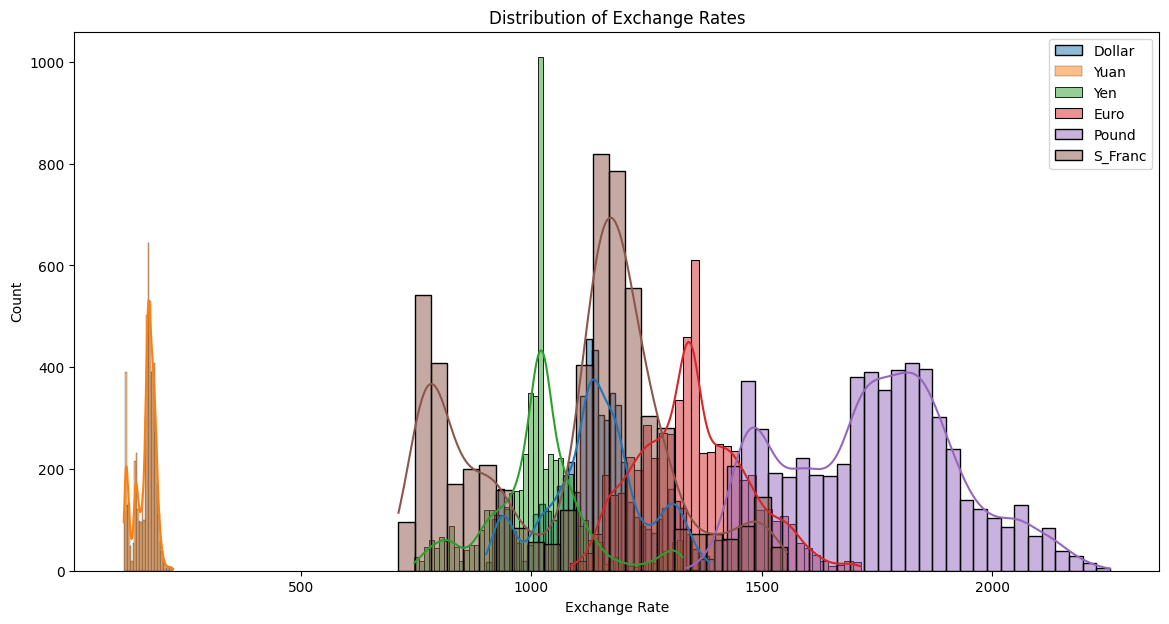

In [ ]:
plt.figure(figsize=(14, 7))
sns.histplot(rates['Dollar'], kde=True, label='Dollar')
sns.histplot(rates['Yuan'], kde=True, label='Yuan')
sns.histplot(rates['Yen'], kde=True, label='Yen')
sns.histplot(rates['Euro'], kde=True, label='Euro')
sns.histplot(rates['Pound_Sterling'], kde=True, label='Pound')
sns.histplot(rates['Swiss_Franc'], kde=True, label='S_Franc')
plt.xlabel('Exchange Rate')
plt.title('Distribution of Exchange Rates')
plt.legend()
plt.show()

###각 통화 사이에서의 상관관계 확인(히트맵으로 시각화)

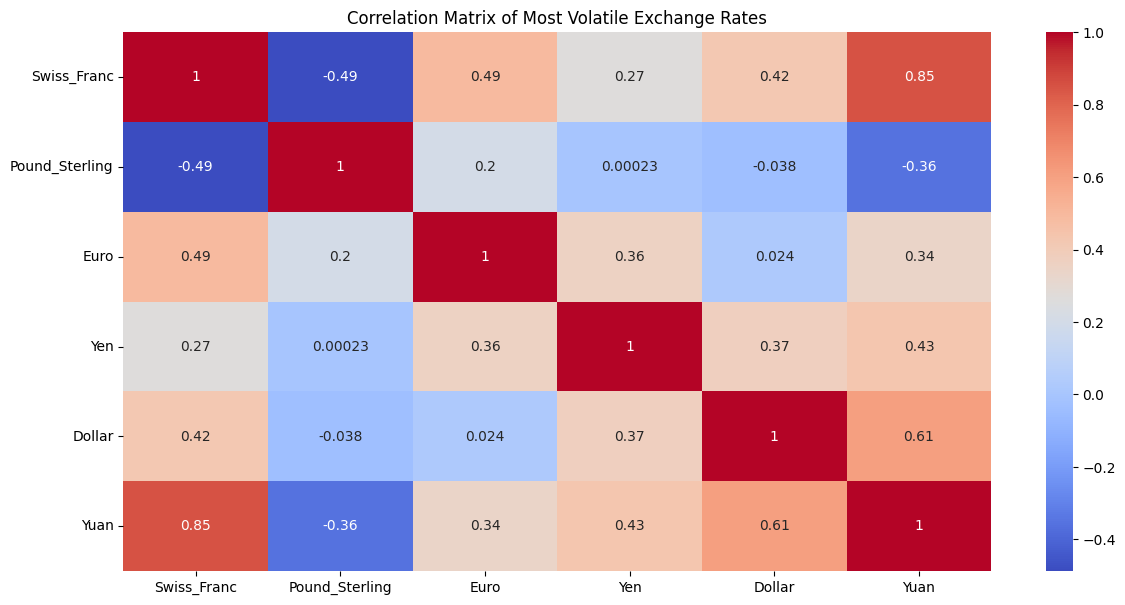

In [ ]:
std_dev = rates[currency_columns].std()

most_volatitle_currencies = std_dev.nlargest(10).index

correlation_matrix = rates[most_volatitle_currencies].corr()

plt.figure(figsize=(14, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Most Volatile Exchange Rates')
plt.show()

## 추세 분석


###'Date' 열을 Rates 테이블의 인덱스로 설정

In [ ]:
rates.set_index('Date', inplace = True)

###각 통화의 이동 평균을 계산

In [ ]:
rates['Dollar_MA'] = rates['Dollar'].rolling(30).mean()           #달러 30일간의 이동 평균을 계산
rates['Yuan_MA'] = rates['Yuan'].rolling(30).mean()               #위안 30일간의 이동 평균을 계산
rates['Yen_MA'] = rates['Yen'].rolling(30).mean()                 #엔 30일간의 이동 평균을 계산
rates['Euro_MA'] = rates['Euro'].rolling(30).mean()               #유로 30일간의 이동 평균을 계산
rates['Pound_MA'] = rates['Pound_Sterling'].rolling(30).mean()    #파운드(영국) 30일간의 이동 평균을 계산
rates['S_Franc_MA'] = rates['Swiss_Franc'].rolling(30).mean()     #스위스 프랑 30일간의 이동 평균을 계산

###원래 데이터와 이동 평균의 데이터에 대한 플롯(달러, 위안, 엔, 유로, 파운드, 스위스 순으로 진행)

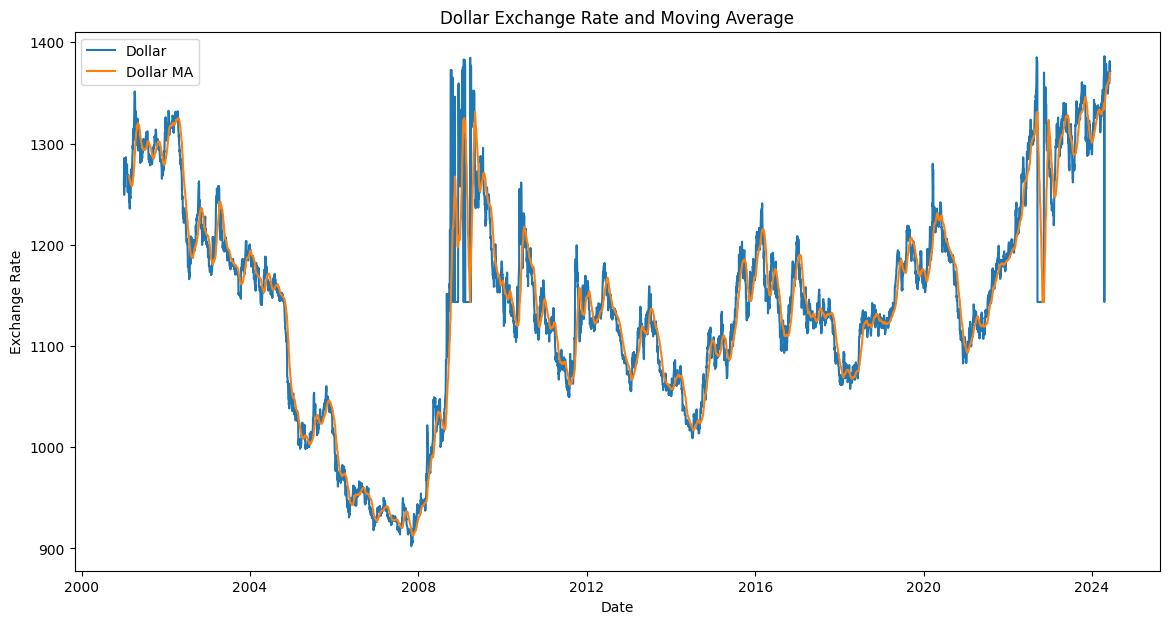

In [ ]:
#달러의 원래 데이터와 이동 평균 데이터에 플롯
plt.figure(figsize=(14, 7))
plt.plot(rates.index, rates['Dollar'], label='Dollar')
plt.plot(rates.index, rates['Dollar_MA'], label='Dollar MA')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Dollar Exchange Rate and Moving Average')
plt.legend()
plt.show()

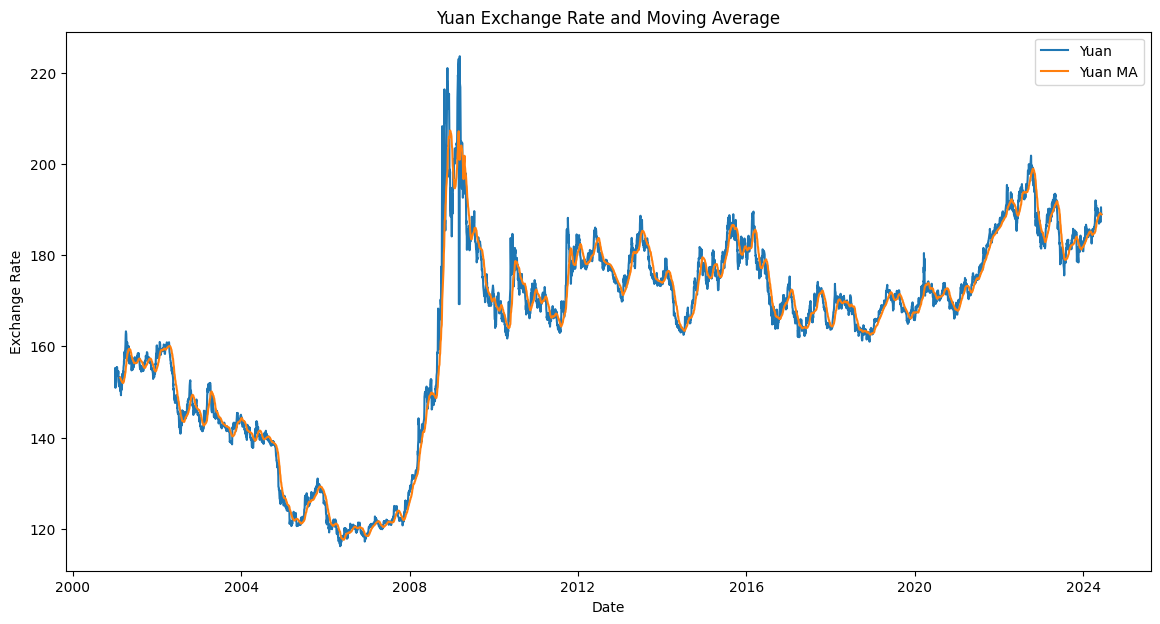

In [ ]:
#위안의 원래 데이터와 이동 평균 데이터에 플롯
plt.figure(figsize=(14, 7))
plt.plot(rates.index, rates['Yuan'], label='Yuan')
plt.plot(rates.index, rates['Yuan_MA'], label='Yuan MA')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Yuan Exchange Rate and Moving Average')
plt.legend()
plt.show()

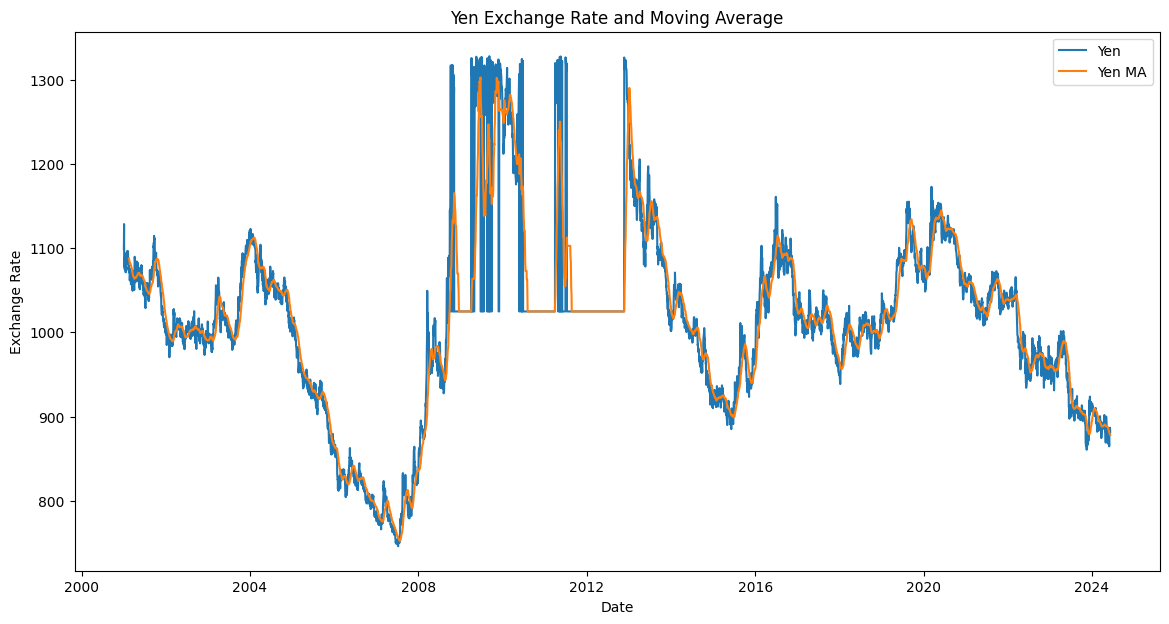

In [ ]:
#엔의 원래 데이터와 이동 평균 데이터에 플롯
plt.figure(figsize=(14, 7))
plt.plot(rates.index, rates['Yen'], label='Yen')
plt.plot(rates.index, rates['Yen_MA'], label='Yen MA')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Yen Exchange Rate and Moving Average')
plt.legend()
plt.show()

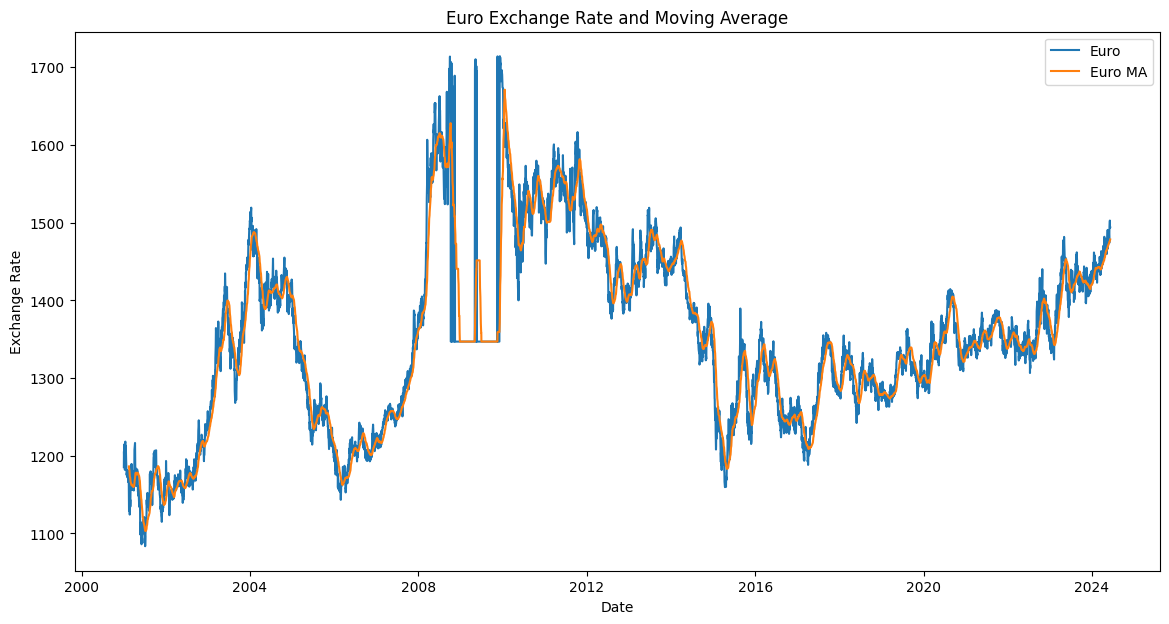

In [ ]:
#유로의 원래 데이터와 이동 평균 데이터에 플롯
plt.figure(figsize=(14, 7))
plt.plot(rates.index, rates['Euro'], label='Euro')
plt.plot(rates.index, rates['Euro_MA'], label='Euro MA')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Euro Exchange Rate and Moving Average')
plt.legend()
plt.show()

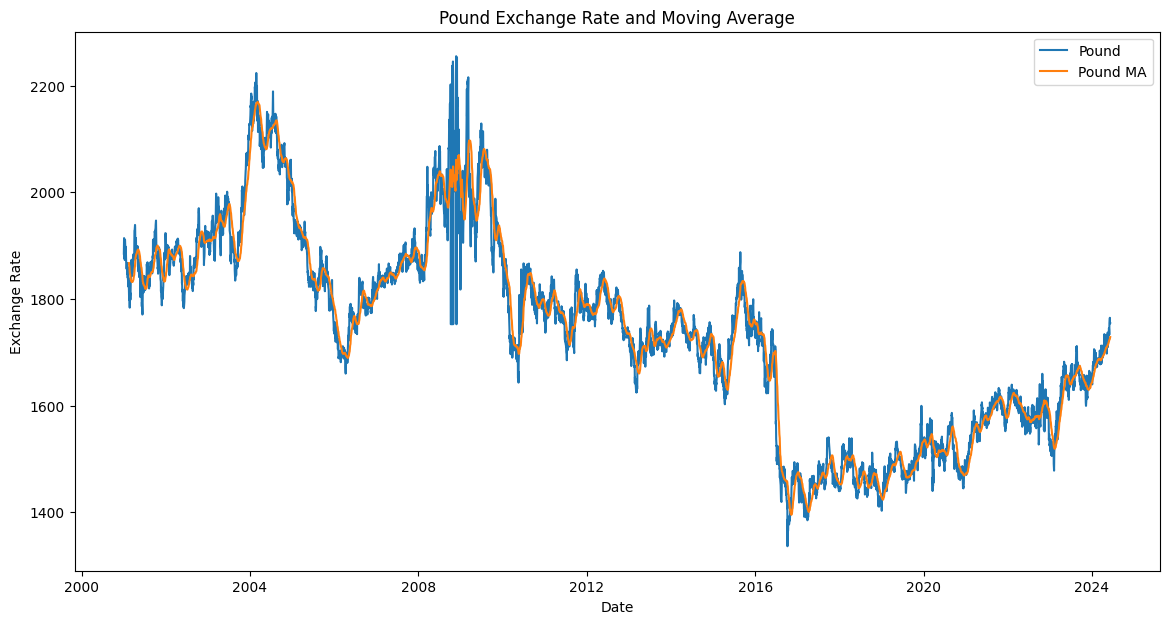

In [ ]:
#파운드의 원래 데이터와 이동 평균 데이터에 플롯
plt.figure(figsize=(14, 7))
plt.plot(rates.index, rates['Pound_Sterling'], label='Pound')
plt.plot(rates.index, rates['Pound_MA'], label='Pound MA')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Pound Exchange Rate and Moving Average')
plt.legend()
plt.show()

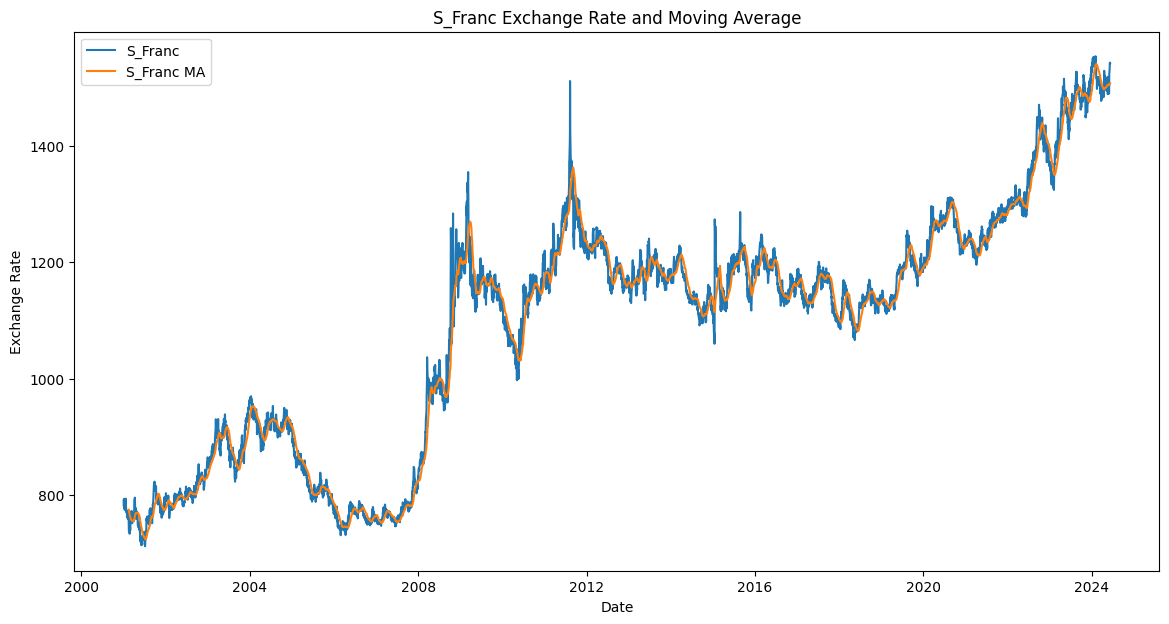

In [ ]:
#스위스 프랑의 원래 데이터와 이동 평균 데이터에 플롯
plt.figure(figsize=(14, 7))
plt.plot(rates.index, rates['Swiss_Franc'], label='S_Franc')
plt.plot(rates.index, rates['S_Franc_MA'], label='S_Franc MA')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('S_Franc Exchange Rate and Moving Average')
plt.legend()
plt.show()

###시계열을 추세, 계절성, 및 잔차 성분을 통해 분해(Subplot을 사용)

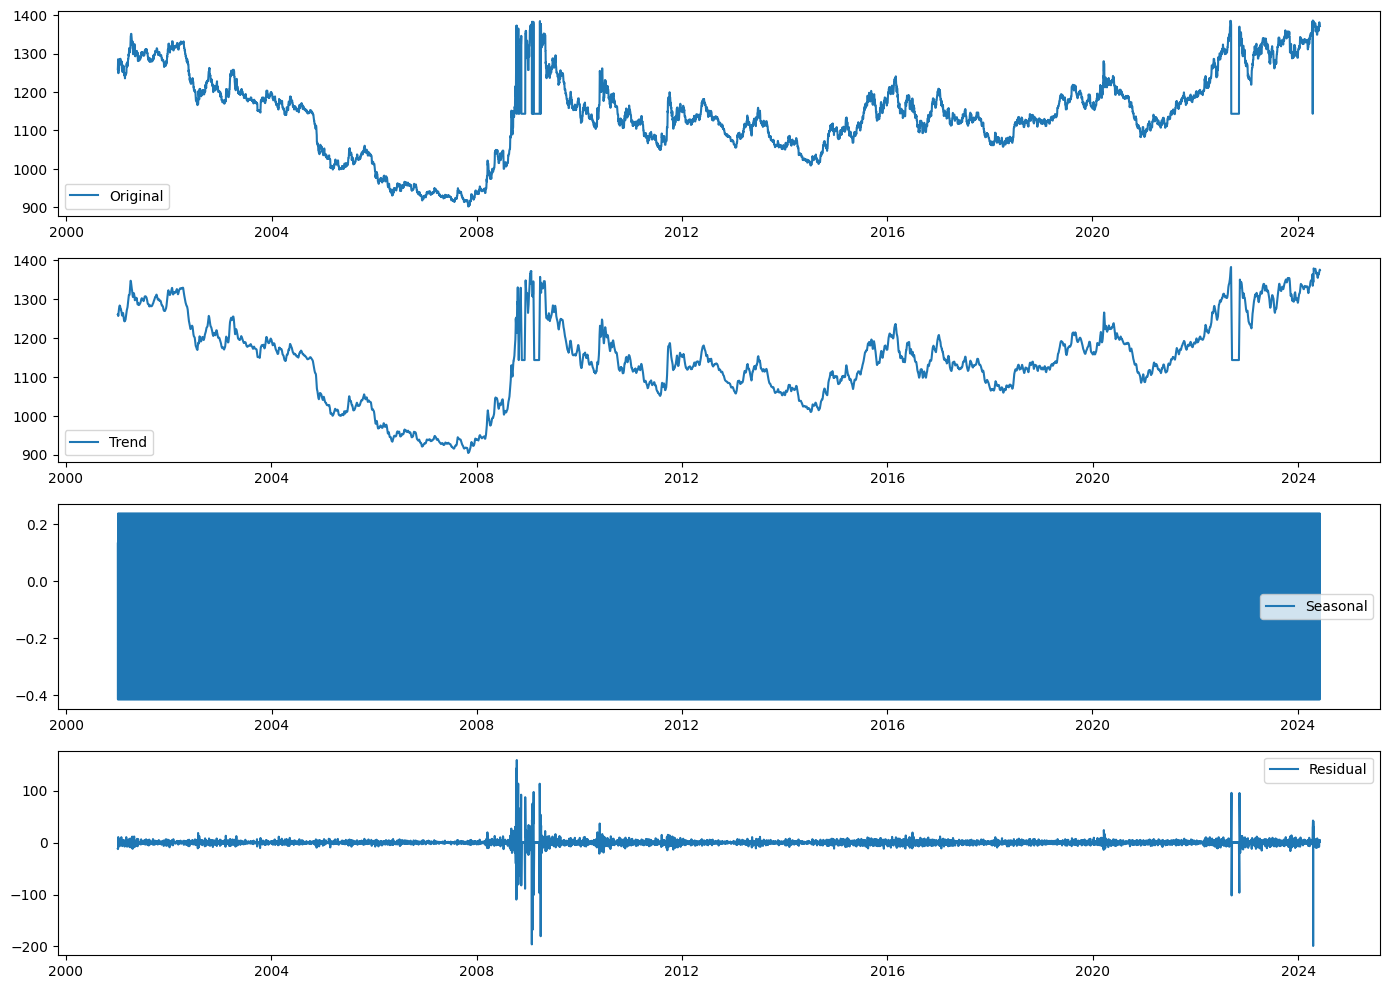

In [ ]:
# 중복된 날짜 제거
rates = rates.loc[~rates.index.duplicated(keep='first')]

#시계열의 주기를 일별로 설정
rates = rates.asfreq('D')

#주기 설정으로 인해 유입되었을 수도 있는 누락된 값을 처리
rates.fillna(method='ffill', inplace=True)

# 시계열 분해(달러)
result = seasonal_decompose(rates['Dollar'], model='additive')

trend = result.trend
seasonal = result.seasonal
residual = result.resid

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(rates['Dollar'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

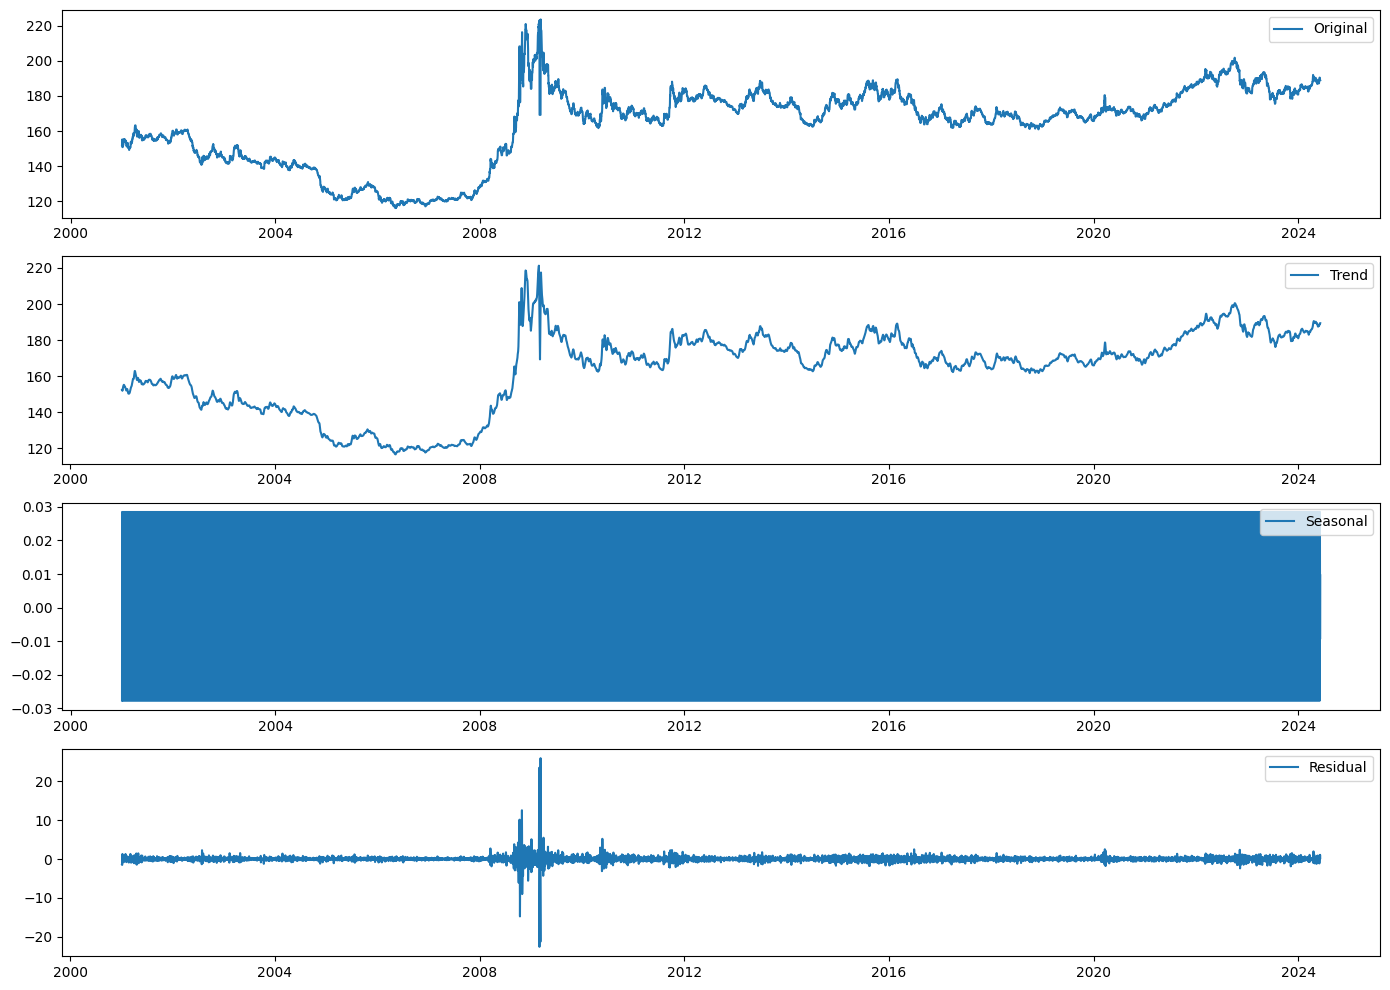

In [ ]:
# 중복된 날짜 제거
rates = rates.loc[~rates.index.duplicated(keep='first')]

#시계열의 주기를 일별로 설정
rates = rates.asfreq('D')

#주기 설정으로 인해 유입되었을 수도 있는 누락된 값을 처리
rates.fillna(method='ffill', inplace=True)

# 시계열 분해(위안)
result = seasonal_decompose(rates['Yuan'], model='additive')

trend = result.trend
seasonal = result.seasonal
residual = result.resid

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(rates['Yuan'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

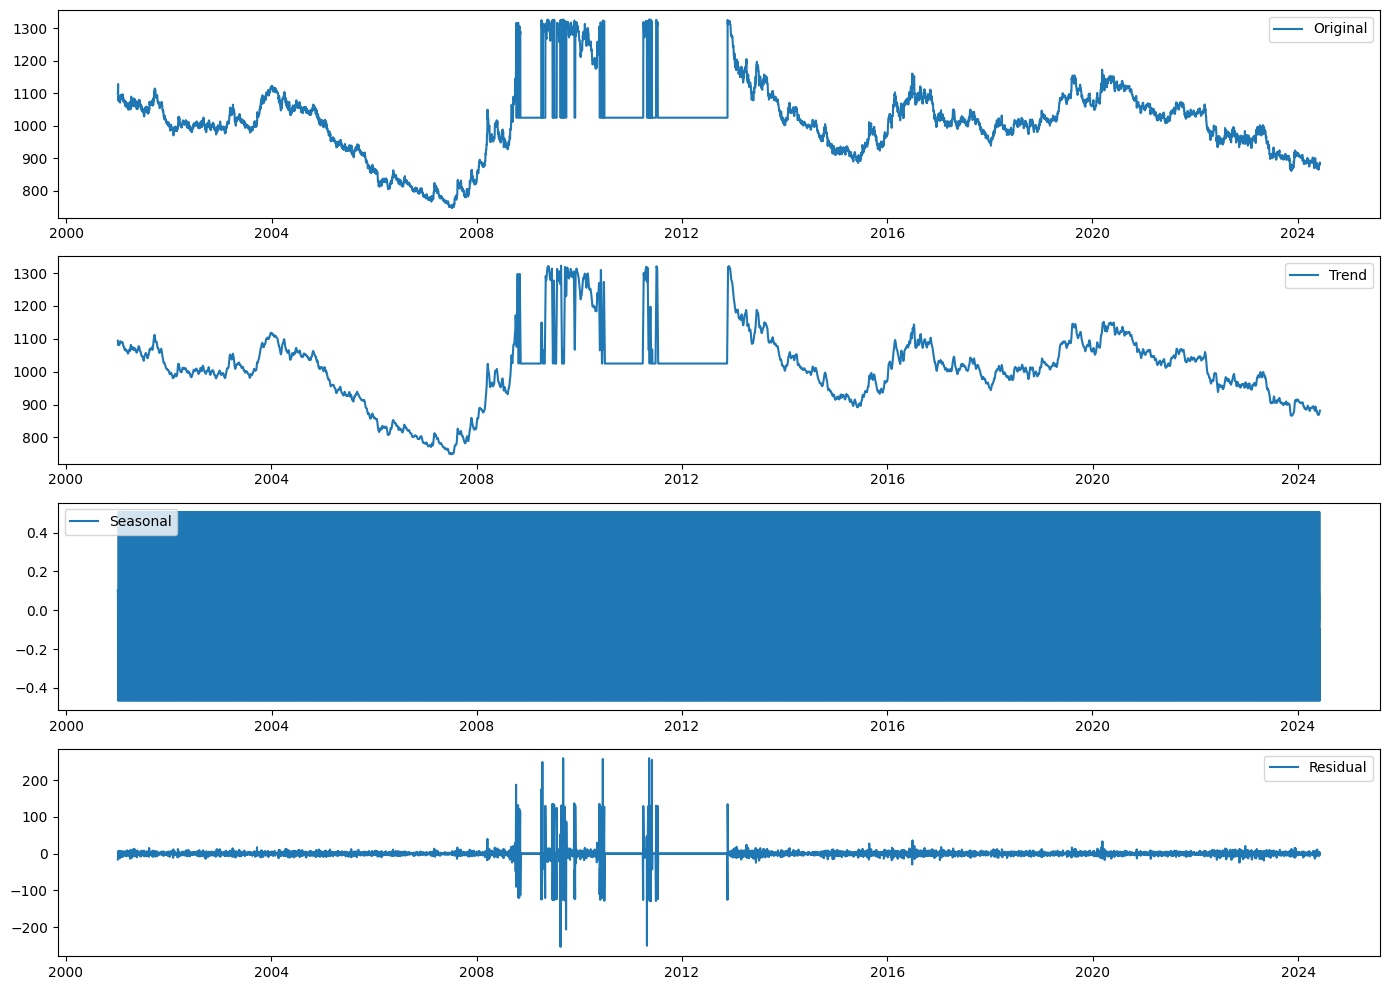

In [ ]:
# 중복된 날짜 제거
rates = rates.loc[~rates.index.duplicated(keep='first')]

#시계열의 주기를 일별로 설정
rates = rates.asfreq('D')

#주기 설정으로 인해 유입되었을 수도 있는 누락된 값을 처리
rates.fillna(method='ffill', inplace=True)

# 시계열 분해(엔)
result = seasonal_decompose(rates['Yen'], model='additive')

trend = result.trend
seasonal = result.seasonal
residual = result.resid

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(rates['Yen'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

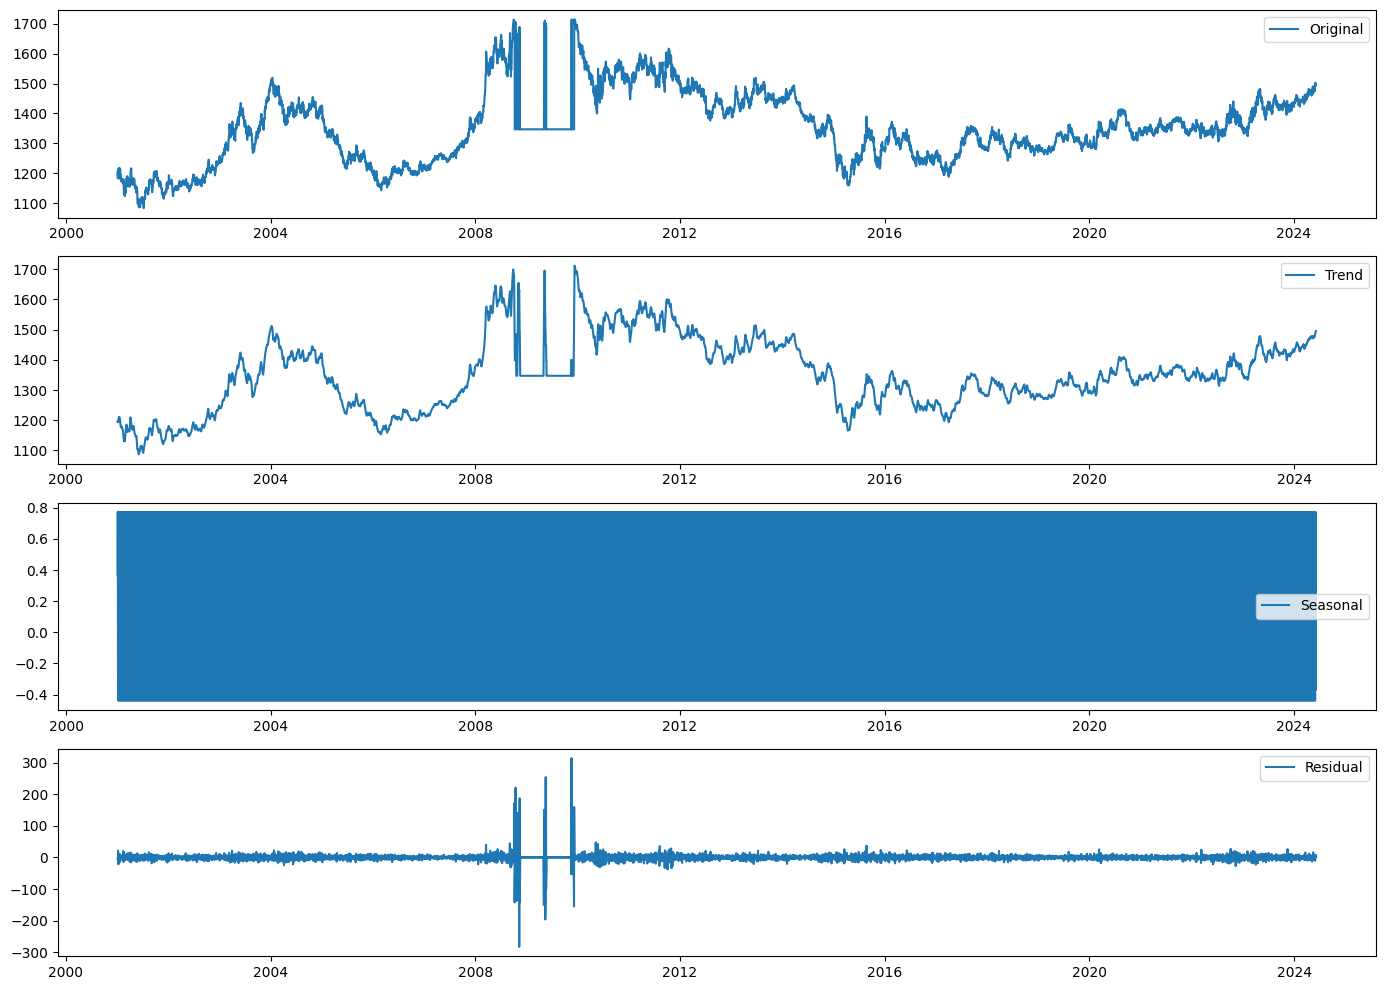

In [ ]:
# 중복된 날짜 제거
rates = rates.loc[~rates.index.duplicated(keep='first')]

#시계열의 주기를 일별로 설정
rates = rates.asfreq('D')

#주기 설정으로 인해 유입되었을 수도 있는 누락된 값을 처리
rates.fillna(method='ffill', inplace=True)

# 시계열 분해(유로)
result = seasonal_decompose(rates['Euro'], model='additive')

trend = result.trend
seasonal = result.seasonal
residual = result.resid

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(rates['Euro'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

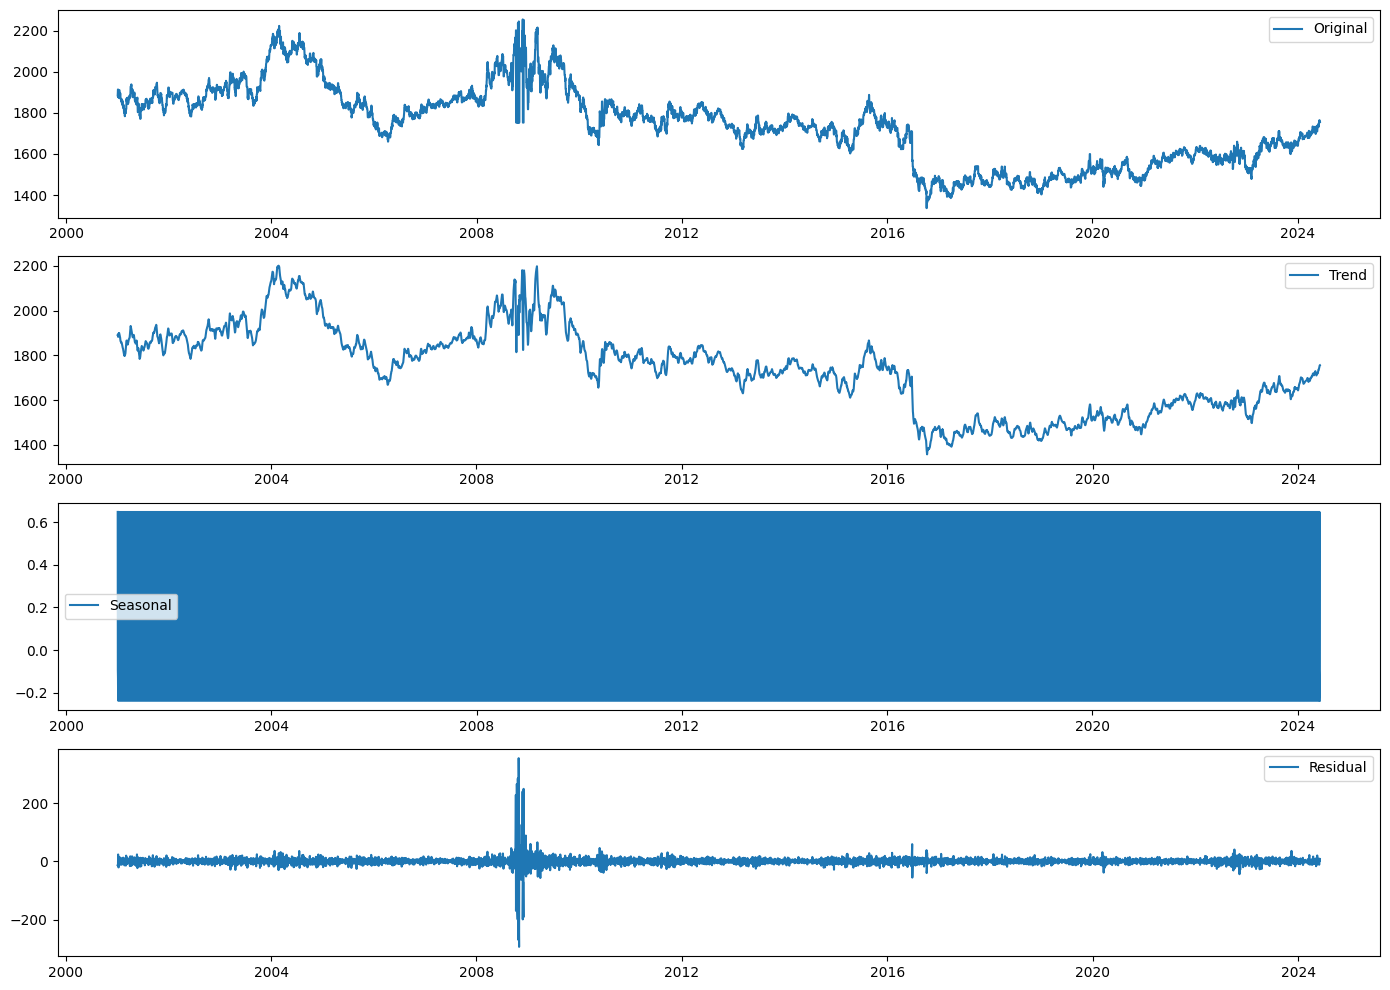

In [ ]:
# 중복된 날짜 제거
rates = rates.loc[~rates.index.duplicated(keep='first')]

#시계열의 주기를 일별로 설정
rates = rates.asfreq('D')

#주기 설정으로 인해 유입되었을 수도 있는 누락된 값을 처리
rates.fillna(method='ffill', inplace=True)

# 시계열 분해(파운드)
result = seasonal_decompose(rates['Pound_Sterling'], model='additive')

trend = result.trend
seasonal = result.seasonal
residual = result.resid

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(rates['Pound_Sterling'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

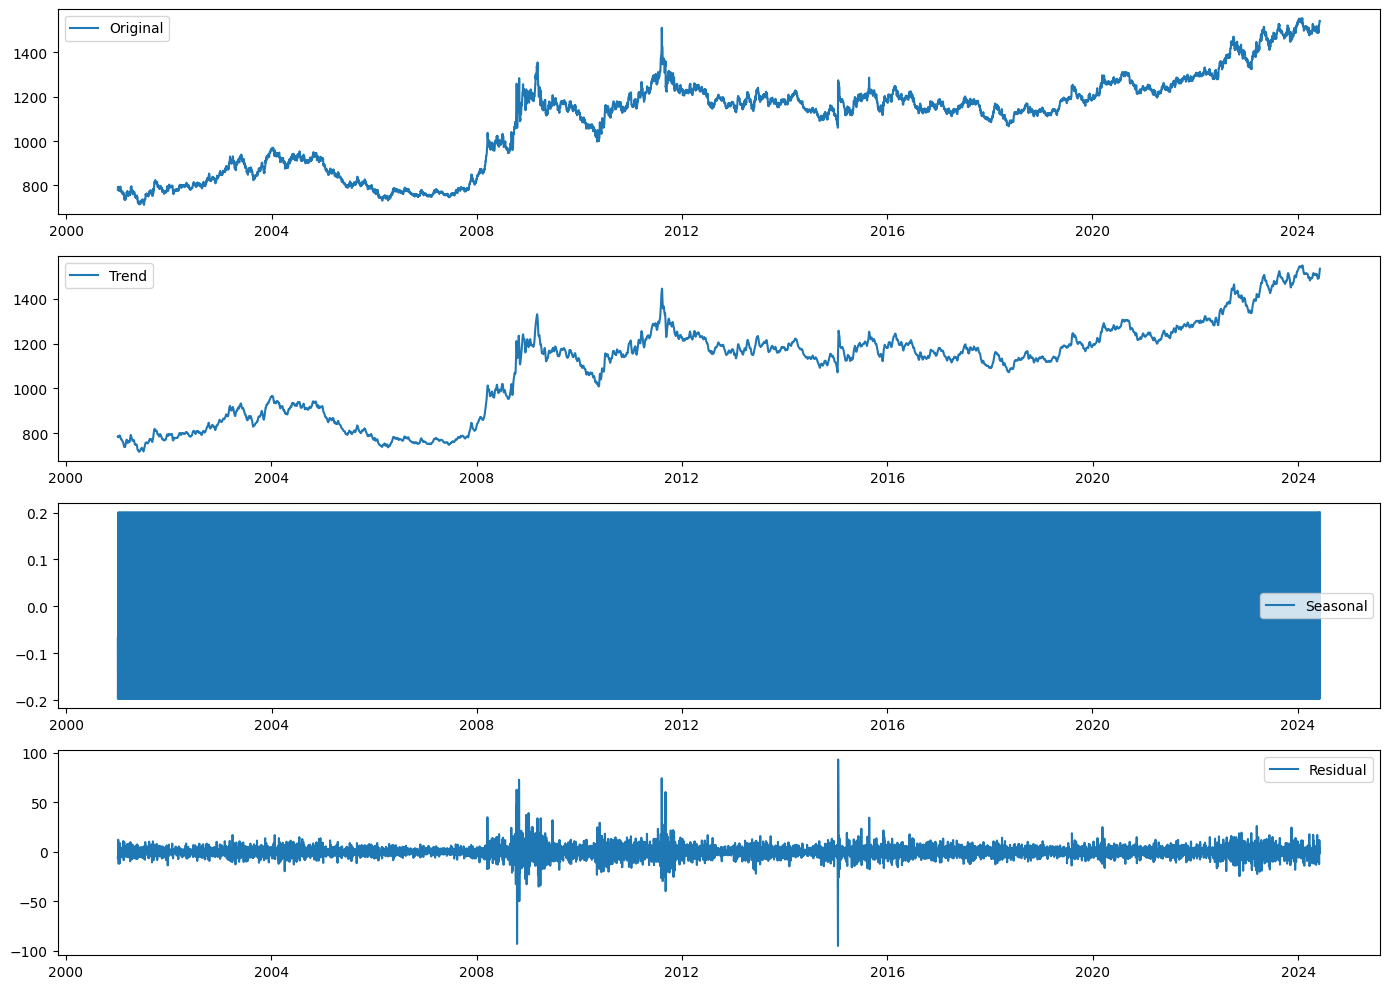

In [ ]:
# 중복된 날짜 제거
rates = rates.loc[~rates.index.duplicated(keep='first')]

#시계열의 주기를 일별로 설정
rates = rates.asfreq('D')

#주기 설정으로 인해 유입되었을 수도 있는 누락된 값을 처리
rates.fillna(method='ffill', inplace=True)

# 시계열 분해(스위스 프랑)
result = seasonal_decompose(rates['Swiss_Franc'], model='additive')

trend = result.trend
seasonal = result.seasonal
residual = result.resid

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(rates['Swiss_Franc'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

##주요 변화의 탐지

###환율의 백분율 변화를 계산

In [ ]:
rates_per_change = rates[currency_columns].pct_change()

###주요 변화에 대한 한계값을 정의

In [ ]:
thres = 0.05      #한계값을 5%로 정의

###주요 변경이 있는 날들을 플래그로 정하는 데이터 프레임 생성

In [ ]:
rates_signi_change = np.abs(rates_per_change) > thres

###각 통화의 주요 변화가 있었던 날짜를 출력

In [ ]:
for currency in currency_columns :
  print(f"Significant changes for {currency} : ")
  print(rates_signi_change[rates_signi_change[currency]].index)
  print("\n")

Significant changes for Dollar : 
DatetimeIndex(['2008-10-08', '2008-10-10', '2008-10-13', '2008-10-14',
               '2008-10-17', '2008-10-24', '2008-10-31', '2008-11-14',
               '2008-12-12', '2009-01-28', '2009-01-29', '2009-02-03',
               '2009-02-05', '2009-02-11', '2009-03-25', '2009-04-01',
               '2009-04-02', '2022-09-15', '2022-11-10', '2024-04-17',
               '2024-04-18'],
              dtype='datetime64[ns]', name='Date', freq=None)


Significant changes for Yuan : 
DatetimeIndex(['2008-10-08', '2008-10-14', '2008-10-17', '2008-10-31',
               '2009-03-03', '2009-03-11'],
              dtype='datetime64[ns]', name='Date', freq=None)


Significant changes for Yen : 
DatetimeIndex(['2008-09-30', '2008-10-07', '2008-10-08', '2008-10-09',
               '2008-10-14', '2008-10-16', '2008-10-17', '2008-10-23',
               '2008-10-31', '2008-11-07', '2009-04-06', '2009-04-09',
               '2009-04-13', '2009-04-14', '2009-05-04', '2009

## 환율의 변동 원인 파악

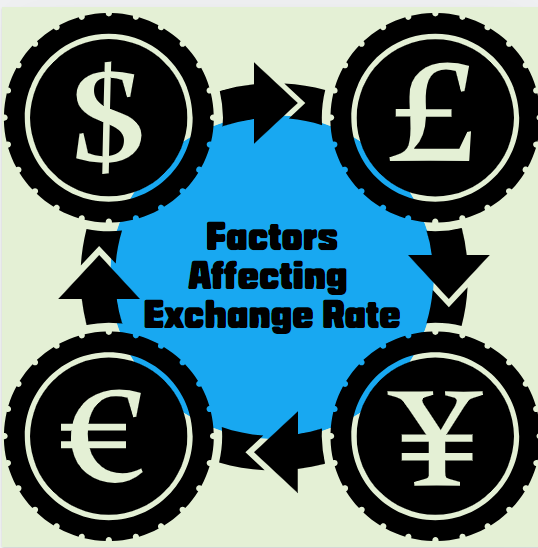

### 환율 변동의 원인 파악하기 (요인 분석)

####환율 변동의 요인을 확인하기 위한 자료 분석

미 금융, 통신 회사인 웨스턴 유니온 사에서는 환율 변동의 원인을 9가지로 판단하였다.

(출처 : [웨스턴 유니온](https://www.westernunion.com/blog/en/gb/currency-fluctuation-what-drives-exchange-rates/))

웨스턴 유니온 사에서 판단한 환율의 변동 요인 9가지

1. 인플레이션(Inflation)

2. 금리(Interest rate)

3. 경기 침체(Recession)

4. 투기(Speculation)

5. 정치의 안정성(Political stability)

6. 경상 수지(Current account deficits)

7. 교역 조건(Terms of trade)

8. 정부 부채(Government debt)

9. 주식 시장(Stock markets)

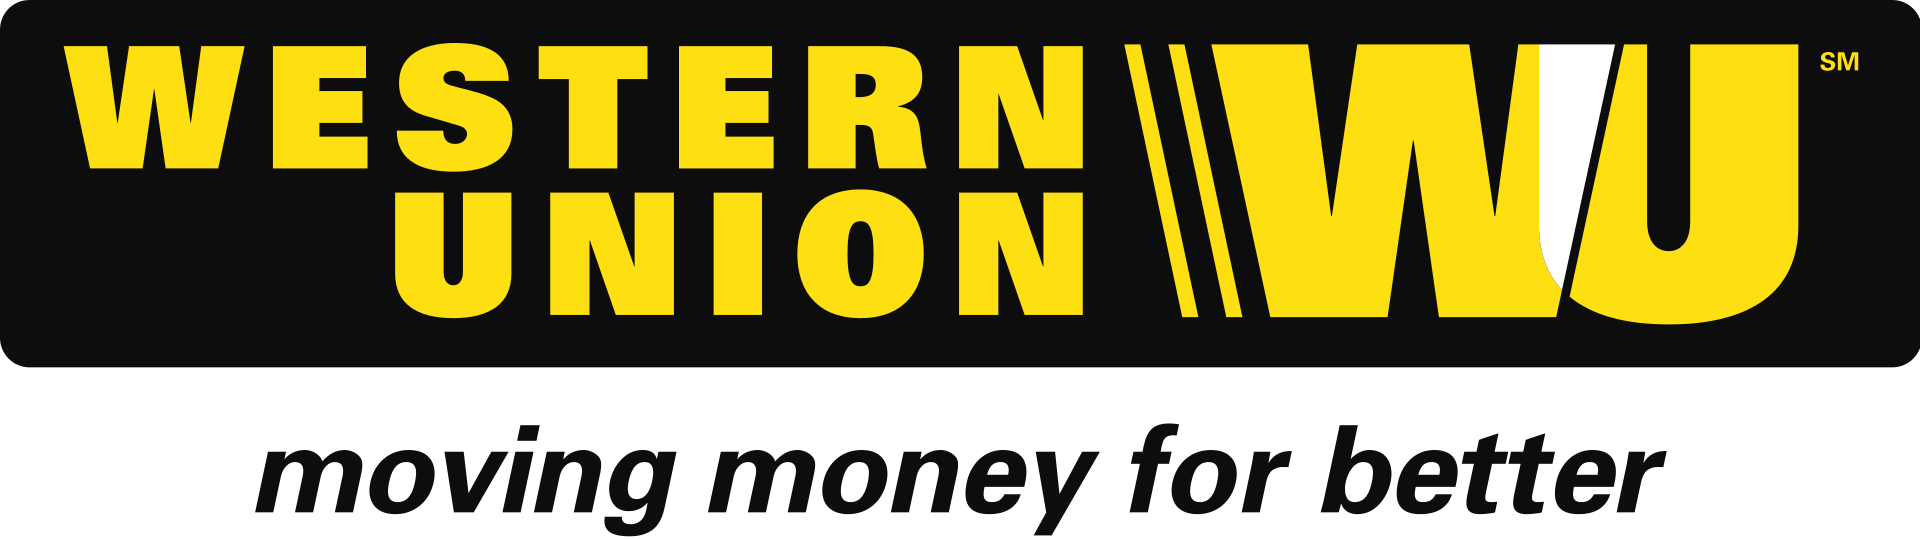

다음 요인 중 직접적인 요인이라고 판단되는 금리(interest rate)와 경기 침체(Recession)를 기반으로 환율 변동을 확인

#### 금리(Interest rate)로 인한 환율 추이

금리(interest rate, 2001-2024) 데이터 로드

In [ ]:
#미국 금리 데이터 로드
d_interest = pd.read_csv('/content/drive/MyDrive/US_interest_rate.csv')
#중국 금리 데이터 로드
c_interest = pd.read_csv('/content/drive/MyDrive/Chi_interest_rate.csv')
#일본 금리 데이터 로드
j_interest = pd.read_csv('/content/drive/MyDrive/Jpn_interest_rate.csv')
#EU 금리 데이터 로드
eu_interest = pd.read_csv('/content/drive/MyDrive/EU_interest_rate.csv')
#영국 금리 데이터 로드
UK_interest = pd.read_csv('/content/drive/MyDrive/UK_interest_rate.csv')
#스위스 금리 데이터 로드
s_interest = pd.read_csv('/content/drive/MyDrive/Swi_interest_rate.csv')

각 국 금리의 데이터와 환율 데이터의 그래프 비교

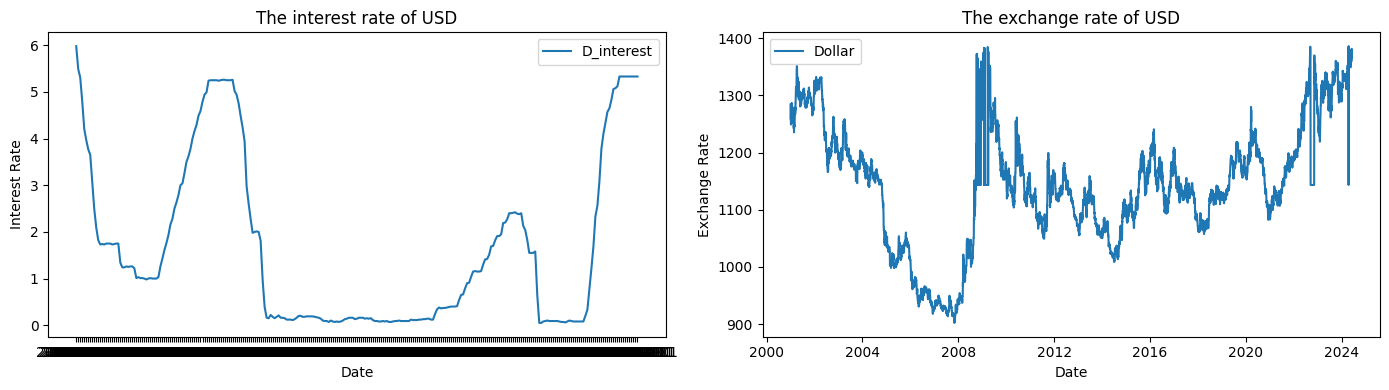

In [ ]:
#미국 금리와 달러 환율 plot 비교
plt.figure(figsize=(14, 4))

#달러 금리의 plot
plt.subplot(1, 2, 1)  #(1, 2, 1)은 1행 2열의 첫 번째 플롯
plt.plot(d_interest['DATE'], d_interest['FEDFUNDS'], label='D_interest')
plt.xlabel('Date')
plt.ylabel('Interest Rate')
plt.title('The interest rate of USD')
plt.legend()

# 달러 환율의 plot
plt.subplot(1, 2, 2)  #(1, 2, 2)은 1행 2열의 두 번째 플롯
plt.plot(rates.index, rates['Dollar'], label='Dollar')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('The exchange rate of USD')
plt.legend()

plt.tight_layout()  #그래프 간격 조정
plt.show()

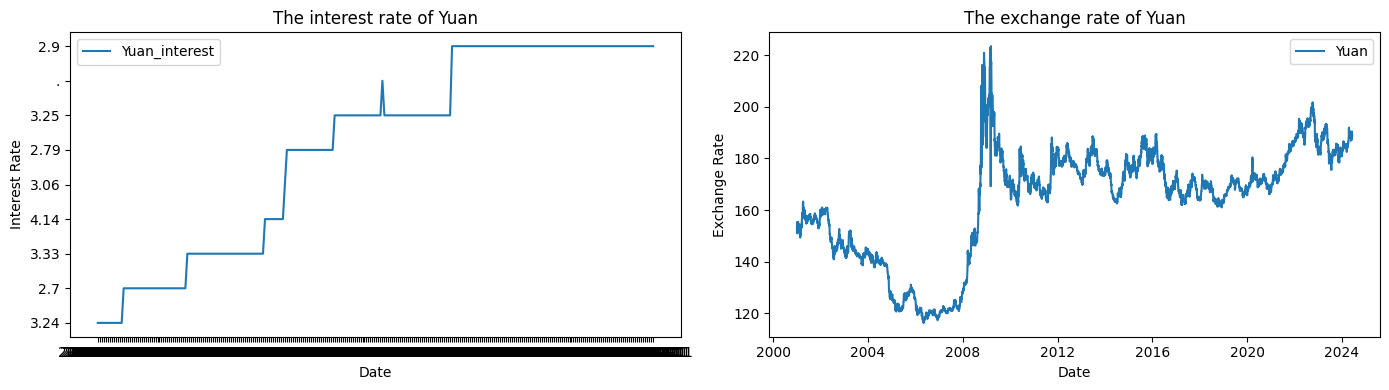

In [ ]:
#중국 금리와 위안 환율 plot 비교
plt.figure(figsize=(14, 4))

#위안 금리의 plot
plt.subplot(1, 2, 1)  #(1, 2, 1)은 1행 2열의 첫 번째 플롯
plt.plot(c_interest['DATE'], c_interest['China'], label='Yuan_interest')
plt.xlabel('Date')
plt.ylabel('Interest Rate')
plt.title('The interest rate of Yuan')
plt.legend()

#위안 환율의 plot
plt.subplot(1, 2, 2)  #(1, 2, 2)은 1행 2열의 두 번째 플롯
plt.plot(rates.index, rates['Yuan'], label='Yuan')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('The exchange rate of Yuan')
plt.legend()

plt.tight_layout()  #그래프 간격 조정
plt.show()

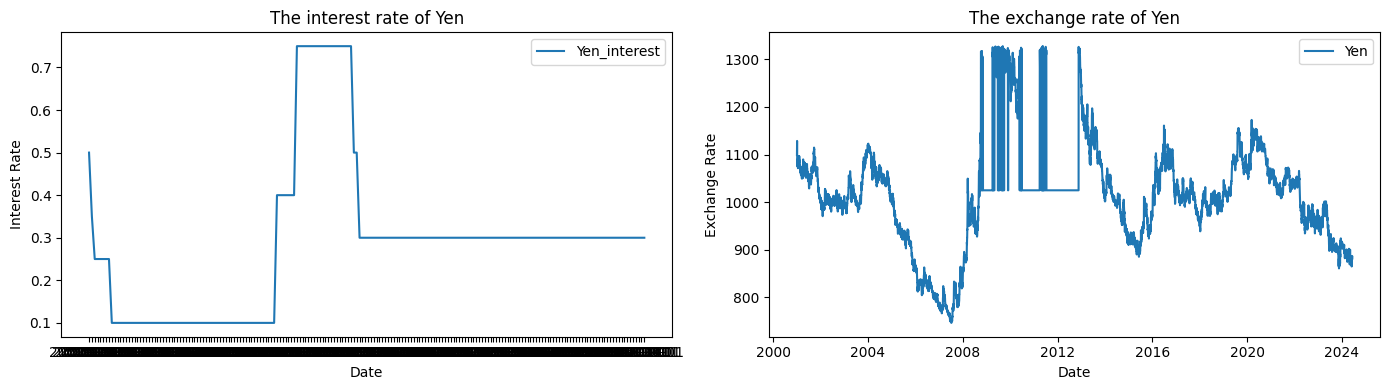

In [ ]:
#일본 금리와 위안 환율 plot 비교
plt.figure(figsize=(14, 4))

#일본 금리의 plot
plt.subplot(1, 2, 1)  #(1, 2, 1)은 1행 2열의 첫 번째 플롯
plt.plot(j_interest['DATE'], j_interest['Japan'], label='Yen_interest')
plt.xlabel('Date')
plt.ylabel('Interest Rate')
plt.title('The interest rate of Yen')
plt.legend()

#엔 환율의 plot
plt.subplot(1, 2, 2)  #(1, 2, 2)은 1행 2열의 두 번째 플롯
plt.plot(rates.index, rates['Yen'], label='Yen')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('The exchange rate of Yen')
plt.legend()

plt.tight_layout()  #그래프 간격 조정
plt.show()

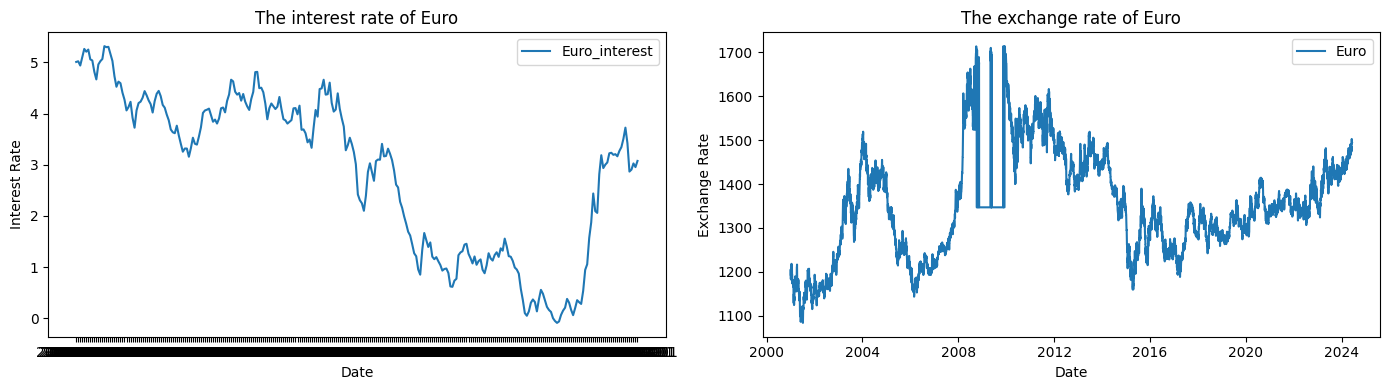

In [ ]:
#EU 금리와  환율 plot 비교
plt.figure(figsize=(14, 4))

#EU 금리의 plot
plt.subplot(1, 2, 1)  #(1, 2, 1)은 1행 2열의 첫 번째 플롯
plt.plot(eu_interest['DATE'], eu_interest['EU'], label='Euro_interest')
plt.xlabel('Date')
plt.ylabel('Interest Rate')
plt.title('The interest rate of Euro')
plt.legend()

#유로 환율의 plot
plt.subplot(1, 2, 2)  #(1, 2, 2)은 1행 2열의 두 번째 플롯
plt.plot(rates.index, rates['Euro'], label='Euro')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('The exchange rate of Euro')
plt.legend()

plt.tight_layout()  #그래프 간격 조정
plt.show()

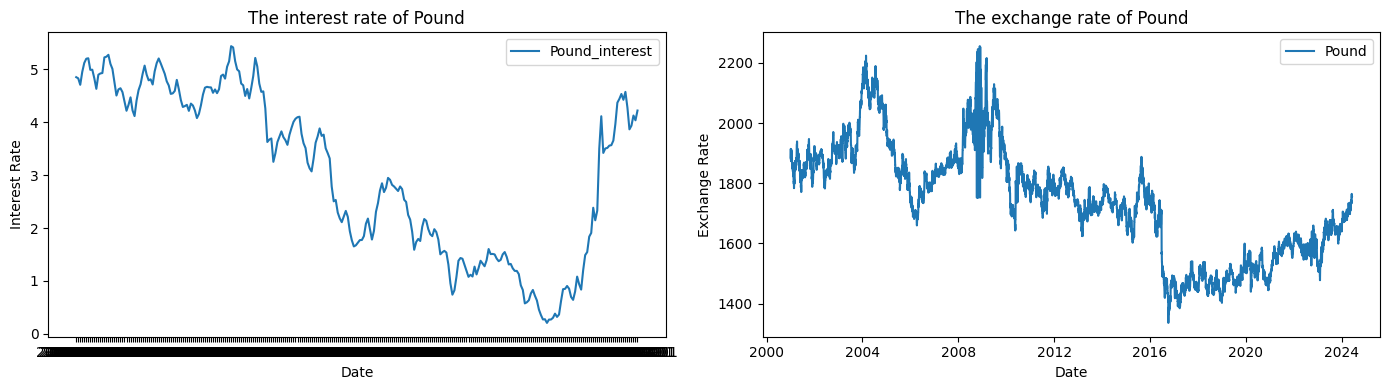

In [ ]:
#영국 금리와  환율 plot 비교
plt.figure(figsize=(14, 4))

#영국 금리의 plot
plt.subplot(1, 2, 1)  #(1, 2, 1)은 1행 2열의 첫 번째 플롯
plt.plot(UK_interest['DATE'], UK_interest['UK'], label='Pound_interest')
plt.xlabel('Date')
plt.ylabel('Interest Rate')
plt.title('The interest rate of Pound')
plt.legend()

#파운드 환율의 plot
plt.subplot(1, 2, 2)  #(1, 2, 2)은 1행 2열의 두 번째 플롯
plt.plot(rates.index, rates['Pound_Sterling'], label='Pound')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('The exchange rate of Pound')
plt.legend()

plt.tight_layout()  #그래프 간격 조정
plt.show()

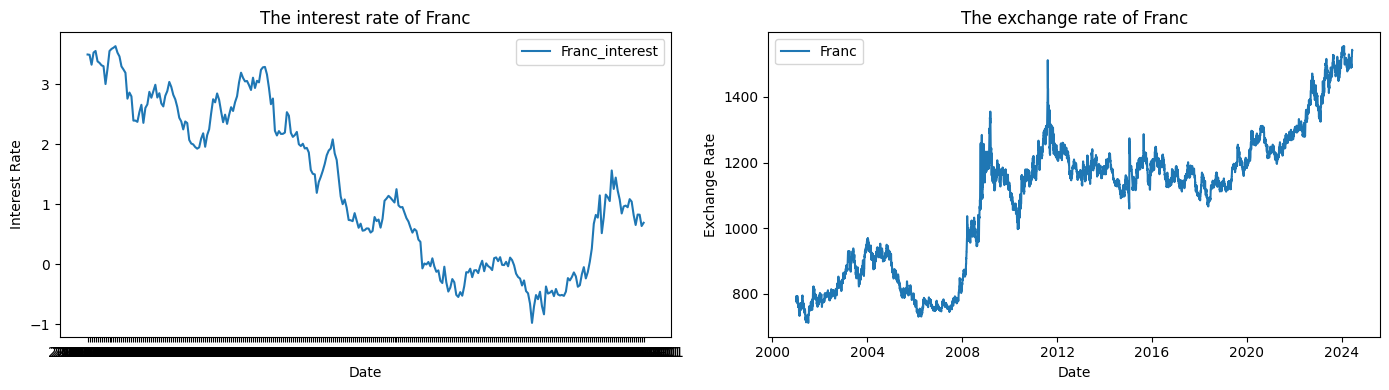

In [ ]:
#스위스 금리와  환율 plot 비교
plt.figure(figsize=(14, 4))

#스위스 금리의 plot
plt.subplot(1, 2, 1)  #(1, 2, 1)은 1행 2열의 첫 번째 플롯
plt.plot(s_interest['DATE'], s_interest['Swiss'], label='Franc_interest')
plt.xlabel('Date')
plt.ylabel('Interest Rate')
plt.title('The interest rate of Franc')
plt.legend()

#프랑(스위스) 환율의 plot
plt.subplot(1, 2, 2)  #(1, 2, 2)은 1행 2열의 두 번째 플롯
plt.plot(rates.index, rates['Swiss_Franc'], label='Franc')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('The exchange rate of Franc')
plt.legend()

plt.tight_layout()  #그래프 간격 조정
plt.show()



> 각 통화별로 금리 plot과 환율 plot를 비교해 보았을 때, 중국의 위안과 스위스의 스위스 프랑을 제외하고는 모두 금리 인상 혹은 인하에 따라 환율 변동이 되었음을 확인할 수 있었다.



#### 세계 금융 위기(2007-2008) 당시 환율 추이


세계 금융 위기(2007-2008) 당시 기축통화(+무역통화, 금,은 제외)의 환율 추이를 확인

달러, 위안, 엔, 유로, 파운드(영국), 프랑(스위스) 순으로 plot을 확인

수월한 확인을 위해 각 통화별로 plot을 생성

In [ ]:
#2006년부터 2010년까지 데이터 필터링
Filtered_date = rates[(rates.index >= '2006-01-01') & (rates.index <= '2010-12-31')]
#경제 위기 시기(2007-2008) 필터링
Crisis_period = rates[(rates.index >= '2007-01-01') & (rates.index <= '2008-12-31')]

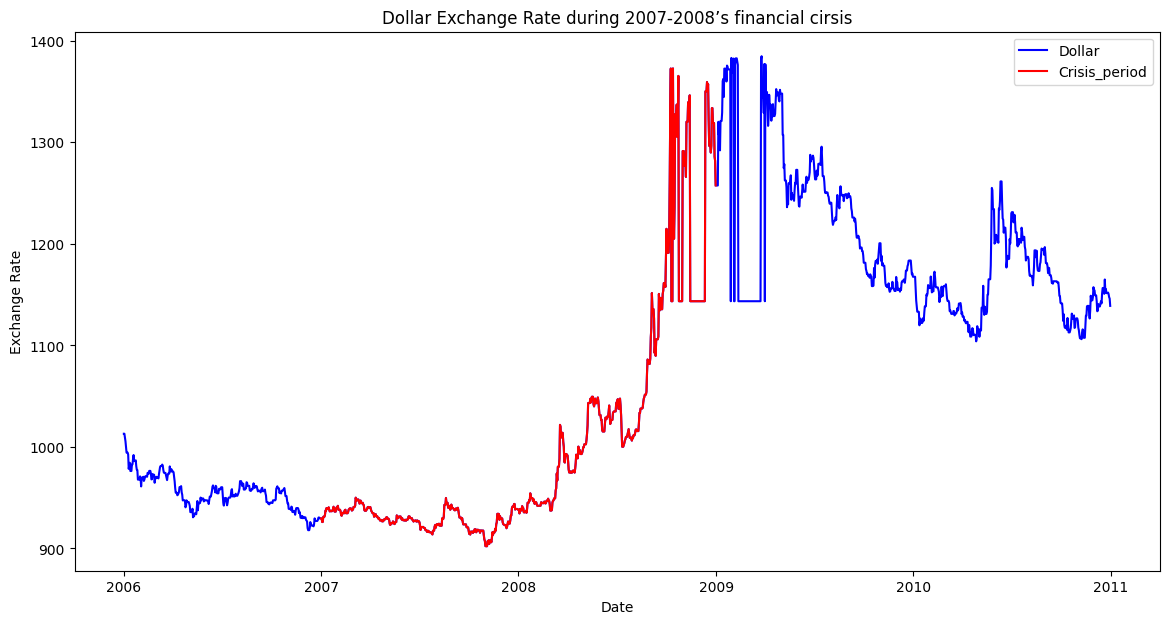

In [ ]:
#달러
plt.figure(figsize=(14, 7))
plt.plot(Filtered_date.index, Filtered_date['Dollar'], label = 'Dollar', color = 'blue')
plt.plot(Crisis_period.index, Crisis_period['Dollar'], label = 'Crisis_period', color = 'red')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Dollar Exchange Rate during 2007-2008’s financial cirsis')
plt.legend()
plt.show()

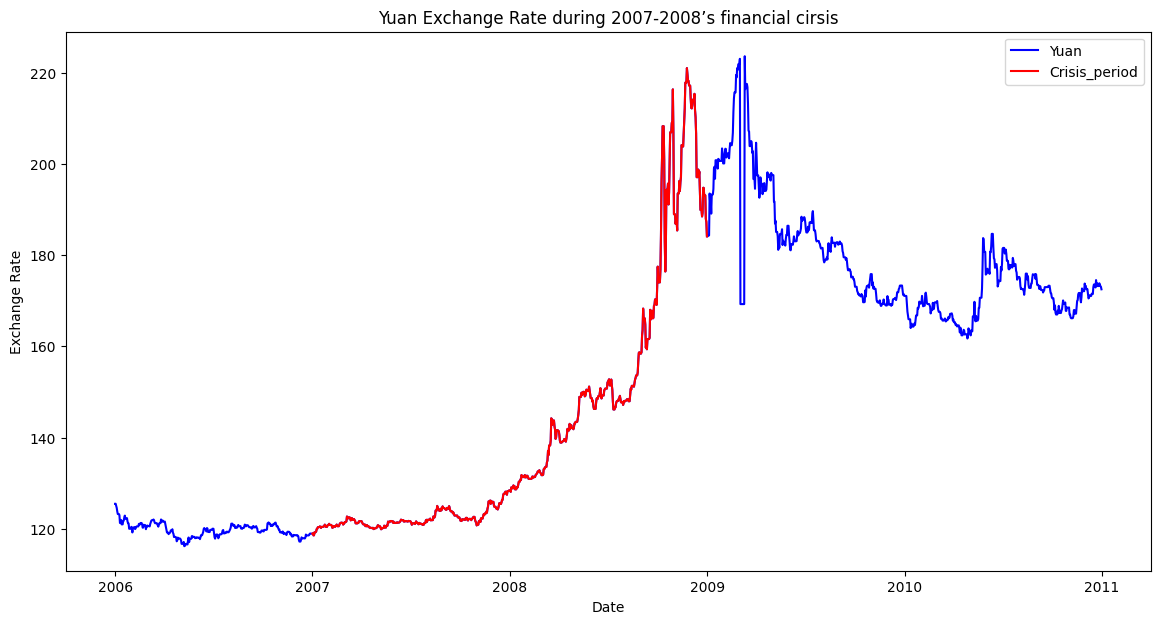

In [ ]:
#위안
plt.figure(figsize=(14, 7))
plt.plot(Filtered_date.index, Filtered_date['Yuan'], label = 'Yuan', color = 'blue')
plt.plot(Crisis_period.index, Crisis_period['Yuan'], label = 'Crisis_period', color = 'red')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Yuan Exchange Rate during 2007-2008’s financial cirsis')
plt.legend()
plt.show()

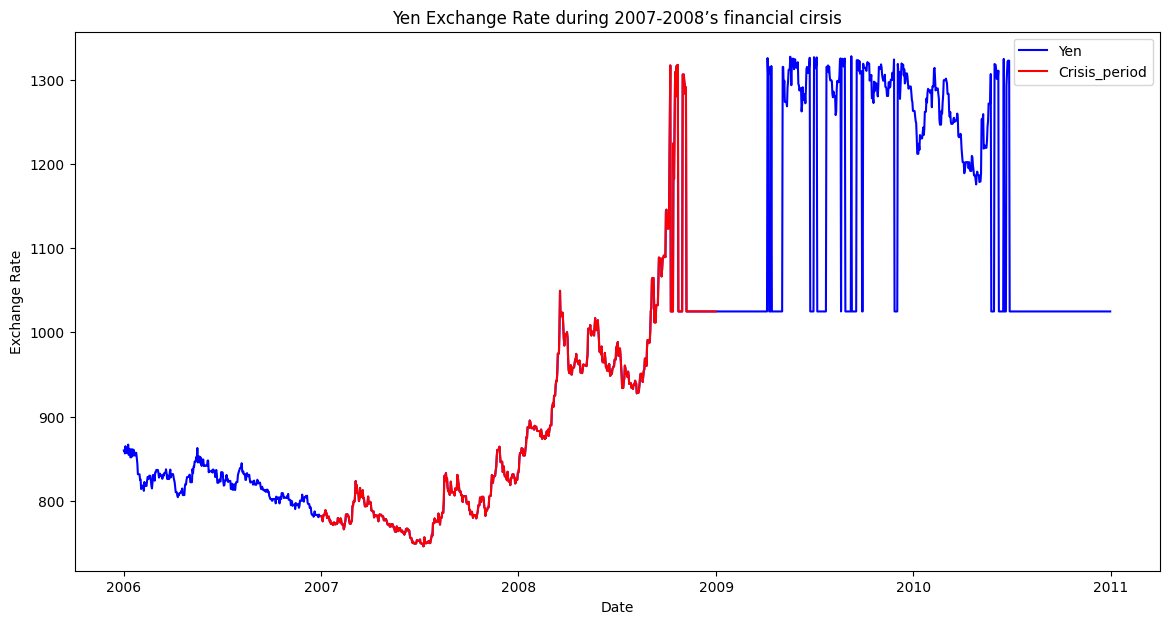

In [ ]:
#엔
plt.figure(figsize=(14, 7))
plt.plot(Filtered_date.index, Filtered_date['Yen'], label = 'Yen', color = 'blue')
plt.plot(Crisis_period.index, Crisis_period['Yen'], label = 'Crisis_period', color = 'red')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Yen Exchange Rate during 2007-2008’s financial cirsis')
plt.legend()
plt.show()

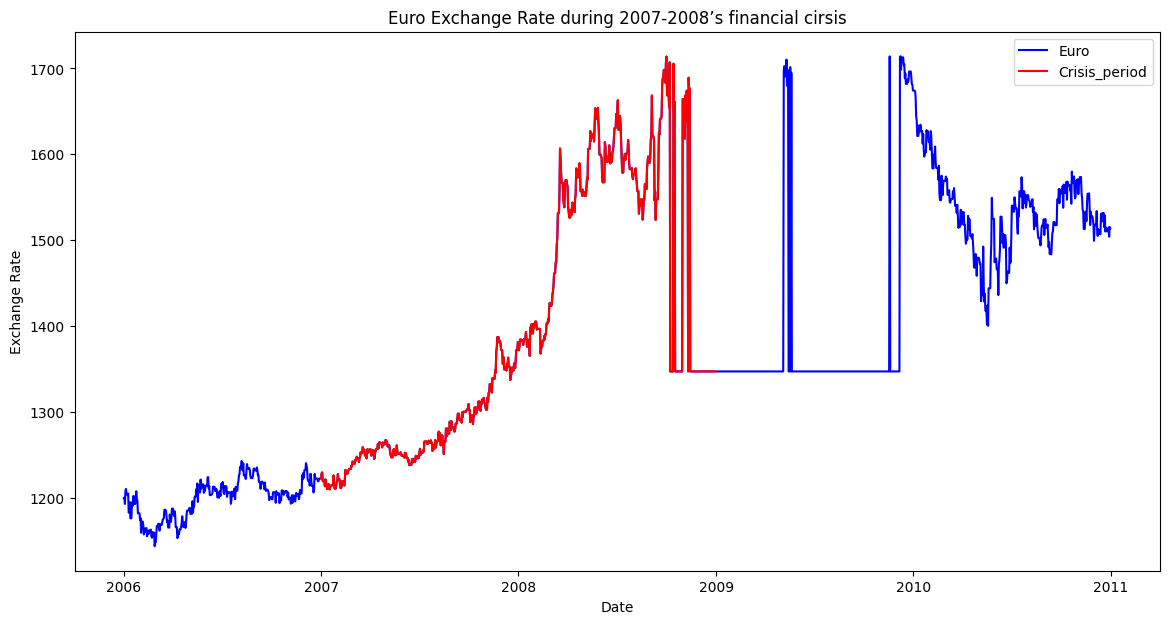

In [ ]:
#유로
plt.figure(figsize=(14, 7))
plt.plot(Filtered_date.index, Filtered_date['Euro'], label = 'Euro', color = 'blue')
plt.plot(Crisis_period.index, Crisis_period['Euro'], label = 'Crisis_period', color = 'red')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Euro Exchange Rate during 2007-2008’s financial cirsis')
plt.legend()
plt.show()

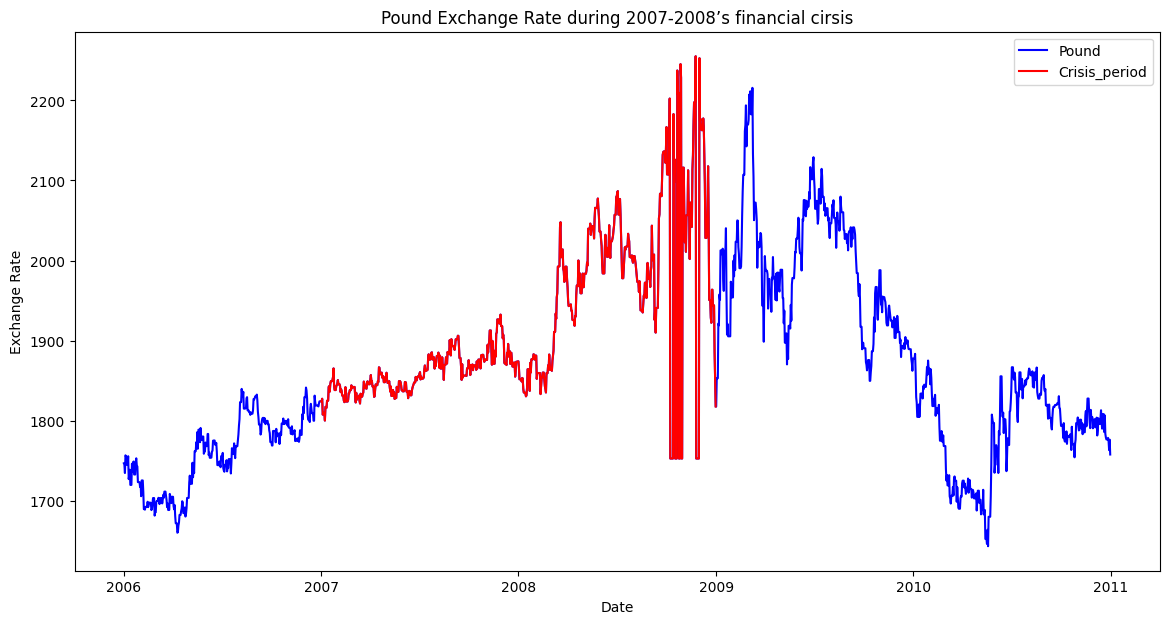

In [ ]:
#파운드(영국)
plt.figure(figsize=(14, 7))
plt.plot(Filtered_date.index, Filtered_date['Pound_Sterling'], label = 'Pound', color = 'blue')
plt.plot(Crisis_period.index, Crisis_period['Pound_Sterling'], label = 'Crisis_period', color = 'red')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Pound Exchange Rate during 2007-2008’s financial cirsis')
plt.legend()
plt.show()

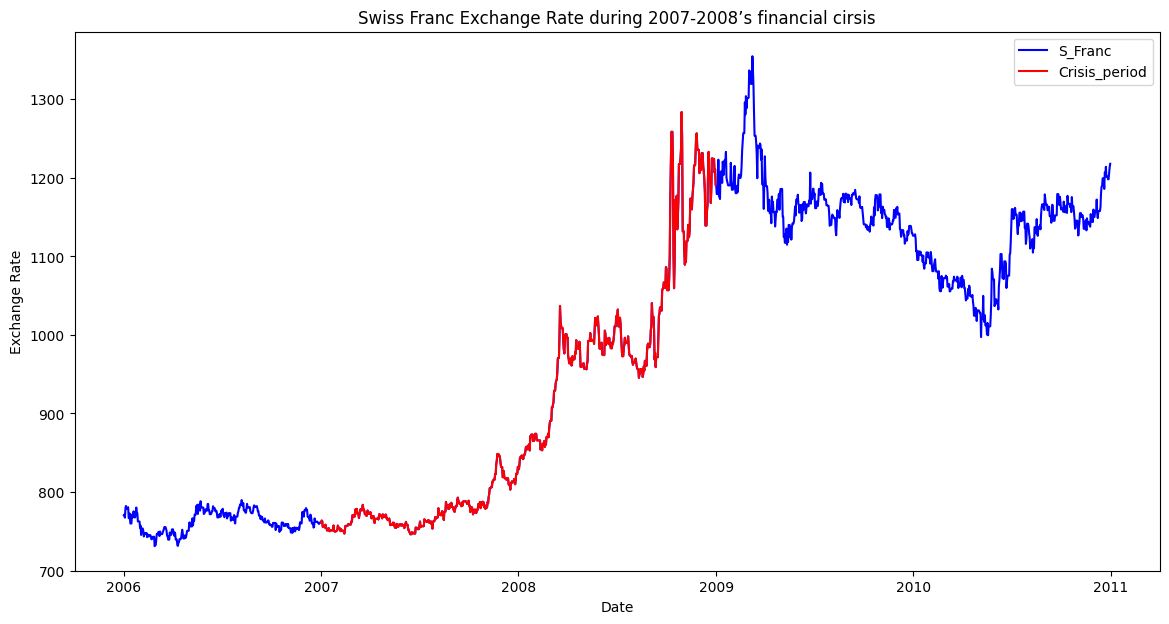

In [ ]:
#프랑(스위스)
plt.figure(figsize=(14, 7))
plt.plot(Filtered_date.index, Filtered_date['Swiss_Franc'], label = 'S_Franc', color = 'blue')
plt.plot(Crisis_period.index, Crisis_period['Swiss_Franc'], label = 'Crisis_period', color = 'red')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Swiss Franc Exchange Rate during 2007-2008’s financial cirsis')
plt.legend()
plt.show()

##환율 추세 예측

###데이터 전처리에서 필요한 라이브러리 임포트(환율 추세 예측)

In [ ]:
#from statsmodels.tsa.arima.model import ARIMA     #ARIMA(자기회귀 누적 이동 평균) 모델 사용 -> 각 통화의 환율 추세를 예측하기 위함
#from statsmodels.tsa.statespace.sarimax import SARIMA
from sklearn.preprocessing import MinMaxScaler    #데이터를 0과 1 사이의 값으로 정규화
from keras.models import Sequential               # Kearas를 사용하여 LSTM 모델 구성
from keras.layers import LSTM, Dense, Dropout     # 위 코드와 동일
from sklearn.metrics import mean_squared_error    # 모델의 예측 정확도 평가

###데이터 시퀀스 생성 함수

In [ ]:
def create_sequences(data, look_back=60):     #시계열 데이터를 LSTM 모델에 적합한 형태로 변환 / 60개의 과거 데이터 사용
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

###데이터 전처리

데이터 정규화 하고 학습용과 테스트용으로 나누어 LSTM 모델 입력에 맞게 변환한다.

In [ ]:
def preprocess_data(data, look_back=60):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data.reshape(-1, 1))

    train_size = int(len(scaled_data) * 0.8)
    train_data = scaled_data[:train_size]
    test_data = scaled_data[train_size - look_back:]

    X_train, y_train = create_sequences(train_data, look_back)
    X_test, y_test = create_sequences(test_data, look_back)

    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    return X_train, y_train, X_test, y_test, scaler

###LSTM 모델 생성 및 학습

In [ ]:
def create_lstm_model(X_train, y_train, epochs=100, batch_size=32):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))     #LSTM 층의 유닛수를 50으로 한다.
    model.add(Dropout(0.2))                                                                 #과적합 방지
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    return model

###예측 함수

In [ ]:
def predict(model, X_test, scaler):
    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)
    return predictions

###미래 예측 함수

In [ ]:
def forecast_future(model, last_sequence, scaler, steps=30):
    future_predictions = []
    current_sequence = last_sequence
    for _ in range(steps):
        prediction = model.predict(current_sequence)
        future_predictions.append(prediction[0, 0])
        current_sequence = np.append(current_sequence[:, 1:, :], np.reshape(prediction, (1, 1, 1)), axis=1)
    future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))
    return future_predictions

###메인 함수

In [ ]:
def main(data, look_back=60, epochs=100, batch_size=32, forecast_steps=30):
    X_train, y_train, X_test, y_test, scaler = preprocess_data(data, look_back)
    model = create_lstm_model(X_train, y_train, epochs, batch_size)
    predictions = predict(model, X_test, scaler)

    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    rmse = np.sqrt(mean_squared_error(y_test_inv, predictions))
    print(f'RMSE: {rmse}')

    last_sequence = X_test[-1].reshape(1, look_back, 1)
    future_predictions = forecast_future(model, last_sequence, scaler, forecast_steps)
    return predictions, future_predictions

###그래프 출력 함수

In [ ]:
def plot_forecast(data, currency, forecast, future, title):
    plt.figure(figsize=(14, 7))
    plt.plot(data.index, data[currency], label=f'Historical {currency} Exchange Rate')

    # 미래 예측 부분 그래프
    future_index = pd.date_range(data.index[-1], periods=len(future), freq='D')
    plt.plot(future_index, future, label=f'Future {currency} Exchange Rate', color='red')

    plt.xlabel('Date')
    plt.ylabel('Exchange Rate')
    plt.title(title)
    plt.legend()
    plt.show()

###데이터 로드 및 예측

In [ ]:
rates = pd.read_csv('/content/drive/MyDrive/KRW_KeyCur_ExRa.csv', index_col='Date', parse_dates=True)

달러 환율 예측

37/37 [==============================] - 2s 21ms/step
RMSE: 6.709476374142969
1/1 [==============================] - 0s 26ms/step


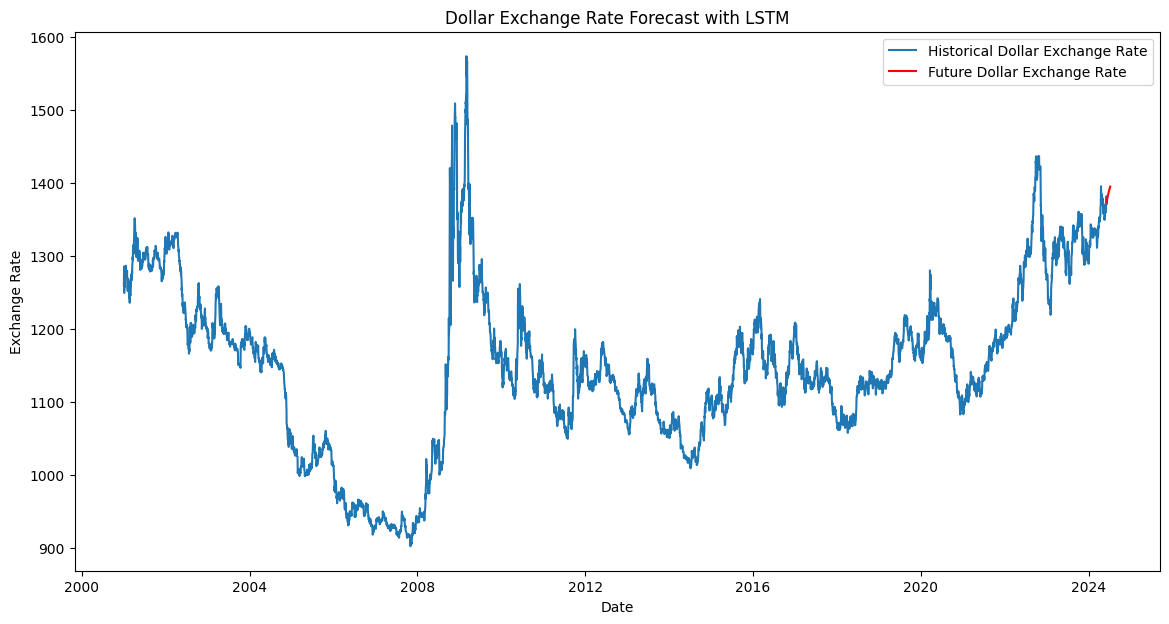

In [ ]:
data = rates['Dollar'].values
predictions, future = main(data, forecast_steps=30)
plot_forecast(rates, 'Dollar', predictions, future, 'Dollar Exchange Rate Forecast with LSTM')

위안 환율 예측

37/37 [==============================] - 2s 22ms/step
RMSE: 1.6720942285303508
1/1 [==============================] - 0s 28ms/step


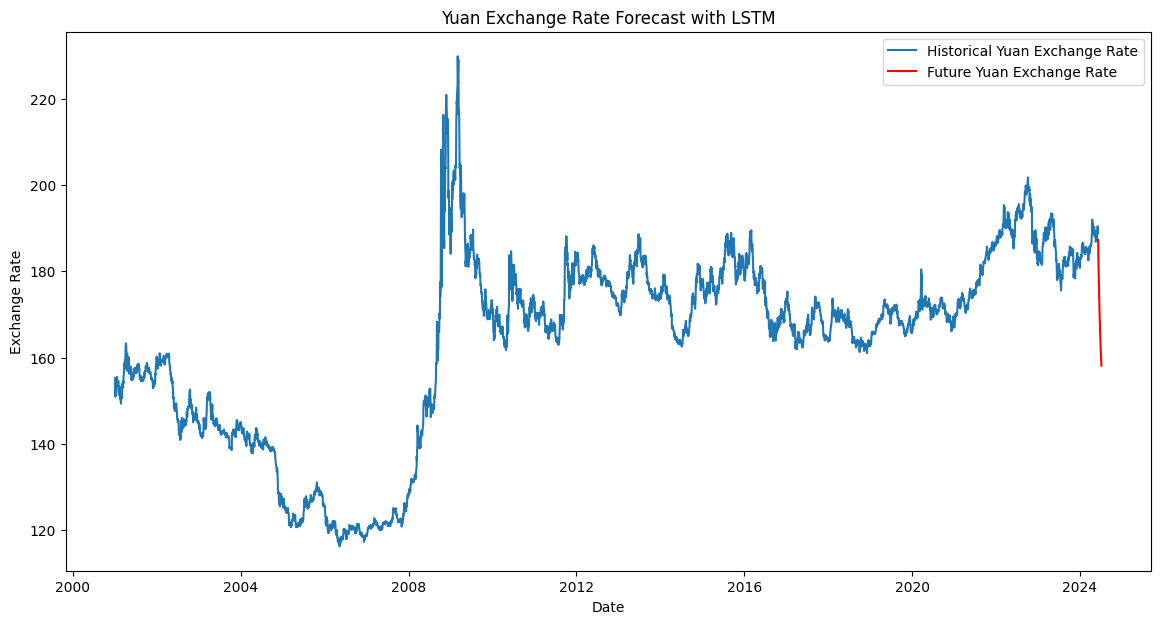

In [ ]:
data = rates['Yuan'].values
predictions, future = main(data, forecast_steps=30)
plot_forecast(rates, 'Yuan', predictions, future, 'Yuan Exchange Rate Forecast with LSTM')

엔 환율 예측

37/37 [==============================] - 1s 17ms/step
RMSE: 7.656460769989723
1/1 [==============================] - 0s 27ms/step


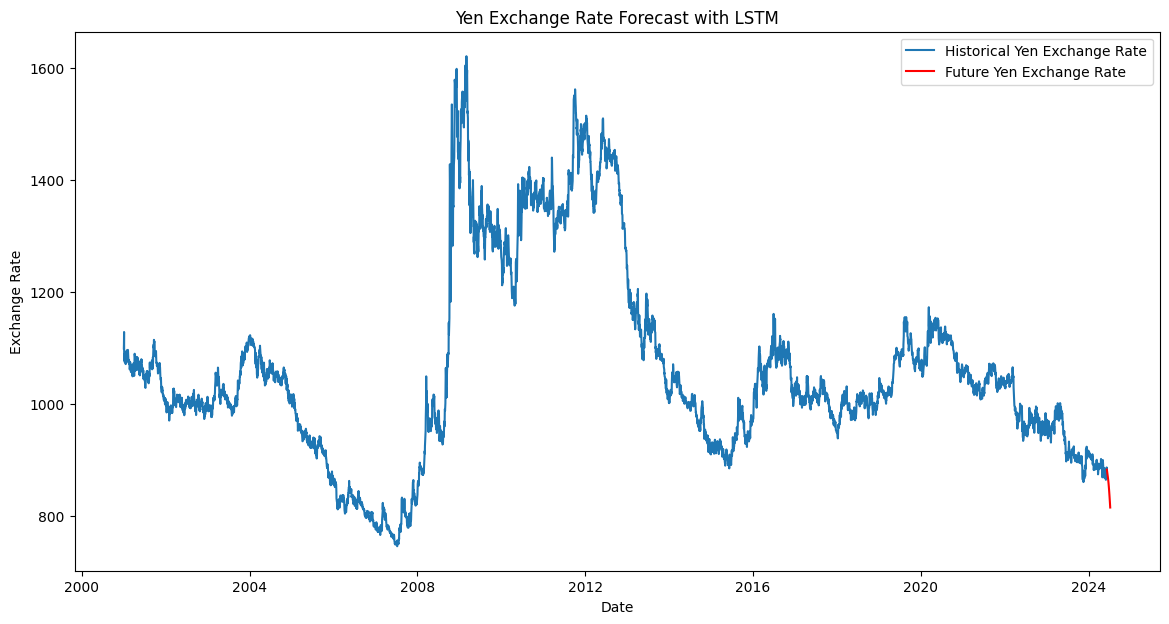

In [ ]:
data = rates['Yen'].values
predictions, future = main(data, forecast_steps=30)
plot_forecast(rates, 'Yen', predictions, future, 'Yen Exchange Rate Forecast with LSTM')

유로 환율 예측

37/37 [==============================] - 1s 15ms/step
RMSE: 8.690870359313472
1/1 [==============================] - 0s 60ms/step


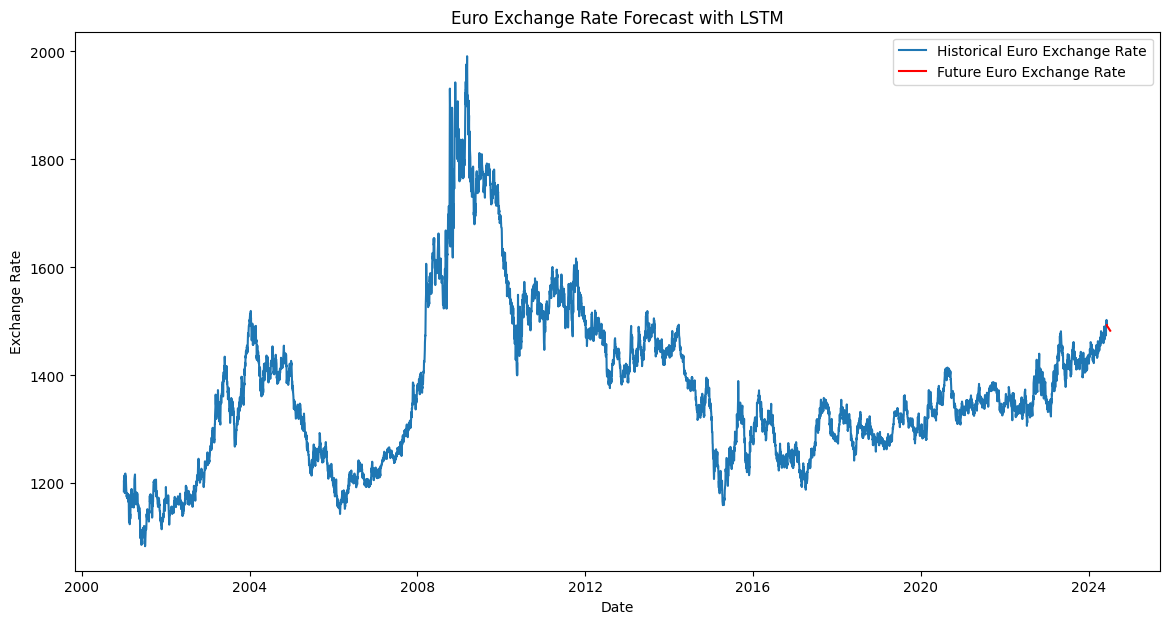

In [ ]:
data = rates['Euro'].values
predictions, future = main(data, forecast_steps=30)
plot_forecast(rates, 'Euro', predictions, future, 'Euro Exchange Rate Forecast with LSTM')

파운드 환율 예측

37/37 [==============================] - 1s 16ms/step
RMSE: 17.979940139769838
1/1 [==============================] - 0s 32ms/step


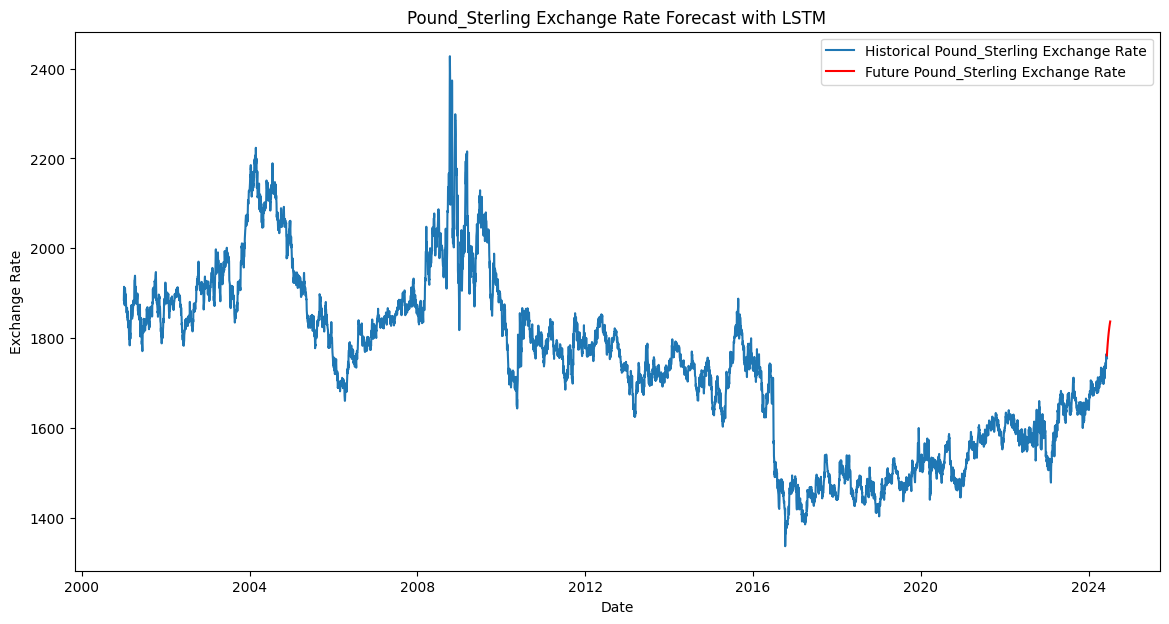

In [ ]:
data = rates['Pound_Sterling'].values
predictions, future = main(data, forecast_steps=30)
plot_forecast(rates, 'Pound_Sterling', predictions, future, 'Pound_Sterling Exchange Rate Forecast with LSTM')

프랑(스위스) 환율 예측

37/37 [==============================] - 2s 21ms/step
RMSE: 14.646361184393268
1/1 [==============================] - 0s 41ms/step


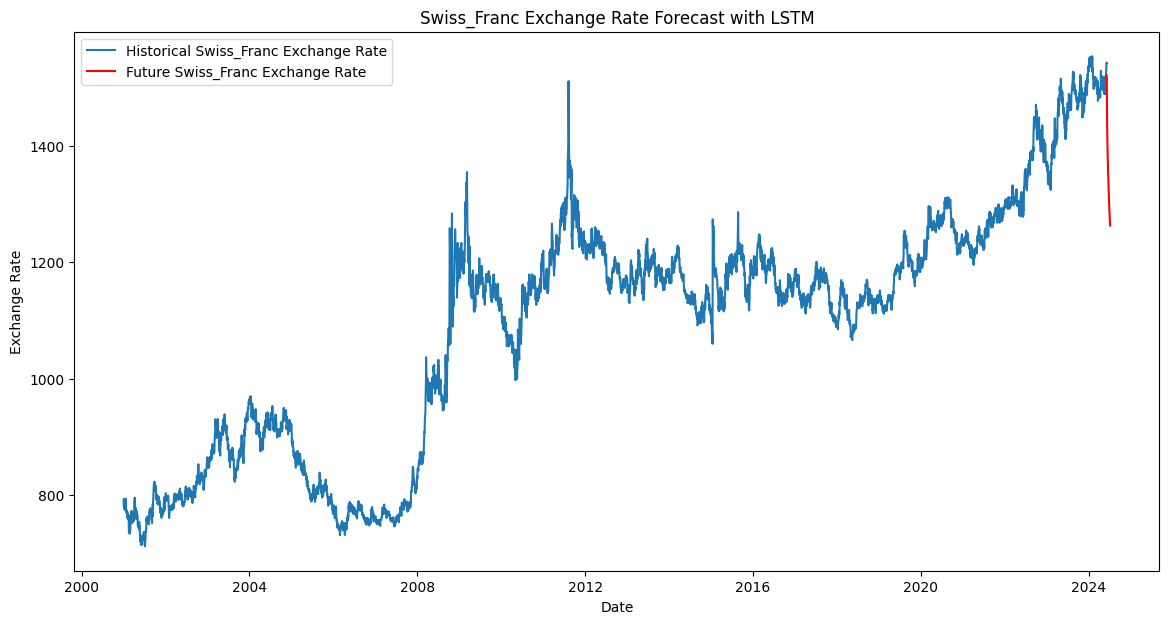

In [ ]:
data = rates['Swiss_Franc'].values
predictions, future = main(data, forecast_steps=30)
plot_forecast(rates, 'Swiss_Franc', predictions, future, 'Swiss_Franc Exchange Rate Forecast with LSTM')

#총 정리


---


과정
*   각 통화 환율의 데이터 전처리
*   이상치 확인 및 계산
*   시각화(원화 가격 기준, 비율 분포, 상관 관계에 대한 히트맵)
*   추세분석(이동 평균 확인)
*   시계열(추세, 계절성, 잔차 성분)으로 분해 및 시각화
*   주요 변화 탐지


---


**시각화를 통해 확인할 수 있었던 사실**

파운드, 유로, 스위스 프랑의 경우에는 2024년을 향할수록 원화 가격이 높아지는 것을 확인할 수 있었다. 2024년 기준으로, 상위 3개 기축통화(준기축통화|무역통화)가 파운드, 유로 스위스 프랑인 것을 확인할 수 있다.


---
**시계열으로 분해 이후 확인할 수 있었던 사실**

달러의 경우 2008 ~ 2010년 시기에 잔차가 상당 발생하였고, 2022 ~ 2024년 시기에 다시 잔차가 발생하는 것을 확인할 수 있다.

위안, 유로, 파운드의 경우 달러와 동일하게 2008 ~ 2010년 시기에 잔차가 발생하는 것을 확인할 수 있다.

엔과 스위스 프랑의 경우 다른 통화는 약간의 차이가 있었다. 엔의 경우 2008 ~ 2012년까지 잔차가 있었고, 스위스 프랑의 경우 2008년을 시작으로 2016년 기간 동안의 잔차가 발생한 것을 확인할 수 있다.


---

**환율 변동의 원인 분석으로 알 수 있었던 사실**

금리 : 중국의 위안과 스위스의 스위스 프랑을 제외한 거의 모든 기축통화(무역통화) 의 환율 변동이 금리에 의해 직접적인 영향을 끼친 것을 Plot을 통해 확인할 수 있었다.

경기 침체 : 세계 경제 위기(2007-2008) 당시에 모든 통화의 환율이 모두 상승한 것을 확인할 수 있었다. 경기 침체가 금리보다 환율에 더 큰 영향을 끼친다는 것을 확인할 수 있었다.

> 2008 ~ 2010년 사이에 모든 통화들이 잔차가 커진 것을 확인할 수 있었고, 2008년에 세계 경제 위기가 영향을 끼친 것이 원인으로 생각할 수 있었다.



(통화의 주요 변화를 확인하고 싶은 경우, 총 정리 위 결과를 보면 된다. 각 통화의 주요 변화가 있는 날짜를 확인할 수 있다.)



---



데이터셋 : [한국은행 경제통계 시스템](https://ecos.bok.or.kr/#/SearchStat)



---



참고 사이트

캐글 : [아시아 - 달러 환율](https://www.kaggle.com/code/joshthyng/dollar-exchange-asian-countries)

캐글 : [환율 데이터 시각화](https://www.kaggle.com/code/luzuker/data-visualization-on-exchange-rates/notebook)

캐글 : [통화 추세 분석](https://www.kaggle.com/code/xreina8/currency-trend-analysis-a-time-series-approach)


---
금리 데이터셋 출처

각국의 통화 금리 데이터셋 출처 : [연방준비제도](https://fred.stlouisfed.org/)

---
